In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

In [3]:
from funcoes_escoragem import *

In [4]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Base

In [ ]:
project_id = 'loft-dl-datascience'

query = '''
WITH
consulta_realizada as(
  SELECT t2.*
  FROM loft-dl-fintech.bronze_credpago_core.imovel_analise as t1
  LEFT JOIN loft-dl-fintech.bronze_credpago_sortinghat.consulta_realizada as t2
    on t1.id_consulta = t2.id_consulta
  where t1._sdc_deleted_at is null and
    REGEXP_CONTAINS(t2.id_externo, r'^[0-9]+$') and
    date(t2.data) >= date('2026-01-01')
),
pc_cidadade_maio2026 as(
  select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_cidade
  where mes_referencia = date('2026-05-01')
),
pc_imob_maio2026 as(
  select * from loft-dl-datascience.ds_risk_cp.blend3_2__variavel_imobiliaria
  where mes_referencia = date('2026-05-01')
),
tb_leads as(
  SELECT
    rf.contract_id,
    date(cf.requested_at) as requested_at,
    cf.tipo,
    cf.tipo_contrato,
    cf.rule,
    cf.bureau_nm,
    cf.modeloBlend,
    rf.approved_products,
    case when '32' in unnest(json_value_array(rf.approved_products)) then 1 else 0 end as flag_pop32,
    rd.product_nm,
    case when cf.modeloBlend = 'BLEND_REGRESSAO_2026' and cf.bureau_nm in ('BLEND_REGRESSAO_2026', 'BVS_CUSTOM', 'HVA3') then 'BLEND2'
        when cf.modeloBlend in ('BLEND3_3', 'BLEND3_4') and cf.bureau_nm in ('BLEND3_3', 'BLEND3_4', 'BVS_CUSTOM', 'HVA4') then 'BLEND3'
        when cf.modeloBlend in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') and cf.bureau_nm in ('BLEND_4', 'BVS_CUSTOM_V2', 'HFT1') then 'BLEND4'
        else 'Outros' end as bureau_nm_ajust,
    case when cf.modeloBlend in ('BLEND3_3', 'BLEND3_4') and cf.bureau_nm in ('BVS_CUSTOM', 'HVA4') then 1
        when cf.bureau_nm in ('BVS_CUSTOM_V2', 'HFT1') then 1
        else 0 end as is_fallback, -- apenas blend3 e blend4
    i.id_imobiliaria,
    i.id_cidade_ibge,
    i.cidade as imovel_cidade,
    i.uf as imovel_uf,
    ad.segmentacao as agency_segmentacao,
    rd.lead_elegivel,
    rd.proposta_iniciada,
    rd.proposta_enviada,
    rd.proposta_aprovada,
    rd.proposta_ativada,
    rd.is_activeted,
    rd.aprovado_motor_mesa,
    coalesce(cf.rating_score_ds, '-1') as rating_score_ds,
    case when coalesce(cf.qtd_proponentes, -1) <= 1 then 1 else 0 end as is_single_proponent,
    ca.blend_regressao_predict_nr,
    pc_cidade.city_pc4_mais_100_contratos__pc_categorias as city_pc4_mais_100_contratos__pc_categorias_maio2026,
    pc_imob.agency_pc4_mais_100_contratos__pc_categorias as agency_pc4_mais_100_contratos__pc_categorias_maio2026,
    cr.*,
    cast(JSON_EXTRACT(json_retornado, '$.blendRegressaoPredict') as float64) AS cr_blendRegressaoPredict
  from loft-dl-fintech.cp_gold.requests_fact as rf
  left join loft-dl-fintech.cp_gold.requests_dim AS rd
    on rf.contract_id = rd.contract_id
  left join loft-dl-fintech.cp_gold.credit_fact as cf
    on rf.contract_id = cf.contract_id
  left join loft-dl-fintech.cp_silver.int_credit_analyses as ca
    on rf.contract_id = ca.contract_id
  left join loft-dl-fintech.bronze_credpago_enriched.imovel as i
    on rf.contract_id = i.id
  left join loft-dl-fintech.cp_gold.agency_dim as ad
    on rd.agency_id = ad.agency_id
  left join consulta_realizada as cr
    on cast(rf.contract_id as FLOAT64) = cast(cr.id_externo as FLOAT64)
  left join pc_cidadade_maio2026 as pc_cidade
    on cast(i.id_cidade_ibge as float64) = cast(pc_cidade.id_cidade_ibge as float64)
  left join pc_imob_maio2026 as pc_imob
    on cast(i.id_imobiliaria as float64) = cast(pc_imob.agency_id as float64)
  where cf.tipo_contrato = 'PF' and
    date(cf.requested_at) >= date('2026-07-01') and
    date(cf.requested_at) < date(current_date())
)
select * from tb_leads
'''

In [ ]:
# df_model = pd.read_gbq(query, project_id=project_id)
# df_model

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,_sdc_table_version,request,_sdc_received_at,_sdc_sequence,documento,rating,_sdc_batched_at,data,result,cr_blendRegressaoPredict
0,4322310,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,[],0,None,...,1786647574343,"{""valor_aluguel"":3500,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903277863868,86447114900,C,2026-08-13 19:42:18.044000+00:00,2026-07-02 09:08:21+00:00,REPROVAR,0.0937
1,4324039,2026-07-02,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,None,...,1786647574343,"{""valor_aluguel"":2050,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903620829552,34393575890,A,2026-08-13 19:42:18.942000+00:00,2026-07-02 12:05:12+00:00,APROVAR,NaN
2,4323023,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,"[25,26,18,20,33,34,35,36,38,40]",0,Flex,...,1786647574343,"{""valor_aluguel"":1650,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903398030855,04483937006,D,2026-08-13 19:42:18.419000+00:00,2026-07-02 10:23:40+00:00,APROVAR,0.2229
3,4326992,2026-07-02,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,41]",0,Smart Plus,...,1786647574343,"{""valor_aluguel"":5000,""matchmaking_on"":false,""...",2026-08-13 19:38:31+00:00,1786649907202943167,22048524818,C,2026-08-13 19:42:18.237000+00:00,2026-07-08 10:38:34+00:00,APROVAR,547.0000
4,4394604,2026-07-20,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,1786647574343,"{""valor_aluguel"":1700,""matchmaking_on"":false,""...",2026-08-13 19:38:40+00:00,1786649914992635790,05916879920,D,2026-08-13 19:42:18.442000+00:00,2026-07-20 14:08:31+00:00,APROVAR,398.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201337,4441019,2026-07-30,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,1786647574343,"{""valor_aluguel"":3700,""matchmaking_on"":false,""...",2026-08-13 19:38:43+00:00,1786649921510136636,57899088100,E,2026-08-13 19:42:31.081000+00:00,2026-07-30 09:29:46+00:00,REPROVAR,326.0000
201338,4447958,2026-07-31,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,1786647574343,"{""valor_aluguel"":1800,""matchmaking_on"":false,""...",2026-08-13 19:38:47+00:00,1786649922477187125,03547294037,E,2026-08-13 19:42:21.403000+00:00,2026-07-31 11:37:57+00:00,REPROVAR,152.0000
201339,4512412,2026-08-14,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,None,...,1786647574343,"{""valor_aluguel"":1500,""matchmaking_on"":false,""...",2026-08-14 18:00:27+00:00,1786730422509989430,11542627230,E,2026-08-14 18:06:07.968000+00:00,2026-08-14 11:17:23+00:00,REPROVAR,NaN
201340,4492344,2026-08-11,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_4,[],0,None,...,1786647574343,"{""valor_aluguel"":2125,""matchmaking_on"":false,""...",2026-08-13 19:38:51+00:00,1786649929019369548,09092321800,E,2026-08-13 19:42:36.263000+00:00,2026-08-11 08:36:25+00:00,REPROVAR,NaN


In [ ]:
# df_model.to_parquet(ANALYTICS_DIR / "df_model_simulacao_blend.parquet")

In [5]:
df_model = pd.read_parquet(ANALYTICS_DIR / "df_model_simulacao_blend.parquet")
df_model

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,_sdc_table_version,request,_sdc_received_at,_sdc_sequence,documento,rating,_sdc_batched_at,data,result,cr_blendRegressaoPredict
0,4322310,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,[],0,None,...,1786647574343,"{""valor_aluguel"":3500,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903277863868,86447114900,C,2026-08-13 19:42:18.044000+00:00,2026-07-02 09:08:21+00:00,REPROVAR,0.0937
1,4324039,2026-07-02,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,None,...,1786647574343,"{""valor_aluguel"":2050,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903620829552,34393575890,A,2026-08-13 19:42:18.942000+00:00,2026-07-02 12:05:12+00:00,APROVAR,NaN
2,4323023,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,"[25,26,18,20,33,34,35,36,38,40]",0,Flex,...,1786647574343,"{""valor_aluguel"":1650,""matchmaking_on"":false,""...",2026-08-13 19:38:27+00:00,1786649903398030855,04483937006,D,2026-08-13 19:42:18.419000+00:00,2026-07-02 10:23:40+00:00,APROVAR,0.2229
3,4326992,2026-07-02,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,41]",0,Smart Plus,...,1786647574343,"{""valor_aluguel"":5000,""matchmaking_on"":false,""...",2026-08-13 19:38:31+00:00,1786649907202943167,22048524818,C,2026-08-13 19:42:18.237000+00:00,2026-07-08 10:38:34+00:00,APROVAR,547.0000
4,4394604,2026-07-20,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,None,...,1786647574343,"{""valor_aluguel"":1700,""matchmaking_on"":false,""...",2026-08-13 19:38:40+00:00,1786649914992635790,05916879920,D,2026-08-13 19:42:18.442000+00:00,2026-07-20 14:08:31+00:00,APROVAR,398.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201337,4441019,2026-07-30,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,1786647574343,"{""valor_aluguel"":3700,""matchmaking_on"":false,""...",2026-08-13 19:38:43+00:00,1786649921510136636,57899088100,E,2026-08-13 19:42:31.081000+00:00,2026-07-30 09:29:46+00:00,REPROVAR,326.0000
201338,4447958,2026-07-31,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,None,...,1786647574343,"{""valor_aluguel"":1800,""matchmaking_on"":false,""...",2026-08-13 19:38:47+00:00,1786649922477187125,03547294037,E,2026-08-13 19:42:21.403000+00:00,2026-07-31 11:37:57+00:00,REPROVAR,152.0000
201339,4512412,2026-08-14,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,None,...,1786647574343,"{""valor_aluguel"":1500,""matchmaking_on"":false,""...",2026-08-14 18:00:27+00:00,1786730422509989430,11542627230,E,2026-08-14 18:06:07.968000+00:00,2026-08-14 11:17:23+00:00,REPROVAR,NaN
201340,4492344,2026-08-11,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_4,[],0,None,...,1786647574343,"{""valor_aluguel"":2125,""matchmaking_on"":false,""...",2026-08-13 19:38:51+00:00,1786649929019369548,09092321800,E,2026-08-13 19:42:36.263000+00:00,2026-08-11 08:36:25+00:00,REPROVAR,NaN


In [11]:
df_model.groupby("bureau_nm_ajust", dropna=False).size()

bureau_nm_ajust
BLEND2      1485
BLEND3    141424
BLEND4     50439
Outros      7994
dtype: int64

In [13]:
df_model[["json_retornado", "request"]]

,json_retornado,request
0,"{""pessoas"":[{""nome"":""CARLOS VENICIO ASSI"",""doc...","{""valor_aluguel"":3500,""matchmaking_on"":false,""..."
1,"{""pessoas"":[{""nome"":""EVERSON DE OLIVEIRA DOS S...","{""valor_aluguel"":2050,""matchmaking_on"":false,""..."
2,"{""pessoas"":[{""nome"":""SAMUEL DOS SANTOS RIBEIRO...","{""valor_aluguel"":1650,""matchmaking_on"":false,""..."
3,"{""pessoas"":[{""nome"":""GILVAN FIGUEIRA DE SOUZA""...","{""valor_aluguel"":5000,""matchmaking_on"":false,""..."
4,"{""pessoas"":[{""nome"":""LUCIA DE LA CARIDAD CRUZ ...","{""valor_aluguel"":1700,""matchmaking_on"":false,""..."
...,...,...
201337,"{""pessoas"":[{""nome"":""HUMBERTO AUGUSTO ARMENIO ...","{""valor_aluguel"":3700,""matchmaking_on"":false,""..."
201338,"{""pessoas"":[{""nome"":""BRUNA KAROLYNA DOS SANTOS...","{""valor_aluguel"":1800,""matchmaking_on"":false,""..."
201339,"{""pessoas"":[{""nome"":"""",""documento"":""1154262723...","{""valor_aluguel"":1500,""matchmaking_on"":false,""..."
201340,"{""pessoas"":[{""nome"":""ANTONIO CARLOS JOSE VIEIR...","{""valor_aluguel"":2125,""matchmaking_on"":false,""..."


In [14]:
def unwrap_payload(obj):
    """Supports old format (message wrapper) and new format (root payload)."""
    if not obj:
        return None
    if isinstance(obj, dict) and "message" in obj:
        return obj["message"]
    return obj


def get_pessoas(obj):
    payload = unwrap_payload(obj)
    return (payload or {}).get("pessoas") or []


def parse_json_col(series):
    return series.apply(lambda x: json.loads(x) if pd.notna(x) and x else None)


# --- json_retornado ---
parsed = parse_json_col(df_model["json_retornado"])
valid_parsed = parsed.dropna()
payload_parsed = valid_parsed.apply(unwrap_payload)

contrato_df = pd.json_normalize(payload_parsed.tolist(), sep="_")
contrato_df.index = payload_parsed.index
contrato_df = contrato_df.add_prefix("message_")

# first person only (pessoas is a list)
pessoa_records = payload_parsed.apply(lambda x: (get_pessoas(x) or [{}])[0])
pessoa_df = pd.json_normalize(pessoa_records.tolist(), sep="_")
pessoa_df.index = payload_parsed.index
pessoa_df = pessoa_df.add_prefix("pessoa_")

# --- request ---
request_parsed = parse_json_col(df_model["request"])
request_valid = request_parsed.dropna()
request_df = pd.json_normalize(request_valid.tolist(), sep="_")
request_df.index = request_valid.index
request_df = request_df.add_prefix("request_")

# unify old (snake_case) and new (camelCase) request schemas
REQUEST_FIELD_ALIASES = {
    "request_valorAluguel": ["request_valor_aluguel"],
    "request_imobiliariaId": ["request_imobiliaria_id"],
    "request_idExterno": ["request_id_externo"],
    "request_imovelTipo": ["request_imovel_tipo"],
    "request_principalDocument": ["request_pessoa_principal_documento"],
}

for target, sources in REQUEST_FIELD_ALIASES.items():
    existing_sources = [c for c in sources if c in request_df.columns]
    if not existing_sources and target not in request_df.columns:
        continue
    if target not in request_df.columns:
        request_df[target] = pd.NA
    for source in existing_sources:
        if target == "request_valorAluguel":
            request_df[target] = request_df[target].combine_first(
                pd.to_numeric(request_df[source], errors="coerce")
            )
        else:
            request_df[target] = request_df[target].combine_first(request_df[source])
        request_df = request_df.drop(columns=[source])

# --- join back ---
df_expandido = (
    df_model
    .join(contrato_df, how="left")
    .join(pessoa_df, how="left")
    .join(request_df, how="left")
)

In [23]:
df_expandido[["request_imovelTipo", "message_blend3Variables_hasPreviousContracts", "message_blend3Variables_hadOverdueInvoiceInPreviousContracts"]]

,request_imovelTipo,message_blend3Variables_hasPreviousContracts,message_blend3Variables_hadOverdueInvoiceInPreviousContracts
0,RESIDENCIAL,NaN,NaN
1,RESIDENCIAL,NaN,NaN
2,RESIDENCIAL,NaN,NaN
3,RESIDENCIAL,False,False
4,RESIDENCIAL,False,False
...,...,...,...
201337,RESIDENCIAL,False,False
201338,RESIDENCIAL,False,False
201339,RESIDENCIAL,False,False
201340,RESIDENCIAL,NaN,NaN


In [25]:
df_expandido = df_expandido.replace({
    "request_imovelTipo": {"RESIDENCIAL": 1, "COMERCIAL": 0}, 
    "message_blend3Variables_hasPreviousContracts": {True: 1, False: 0},
    "message_blend3Variables_hadOverdueInvoiceInPreviousContracts": {True: 1, False: 0}
}
)

In [27]:
df_expandido.groupby("bureau_nm_ajust", dropna=False).size()

bureau_nm_ajust
BLEND2      1485
BLEND3    141424
BLEND4     50439
Outros      7994
dtype: int64

In [ ]:
df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND2"][
    ["bureau_nm_ajust",
    "message_scores_BVS_CUSTOM_V2", "message_scores_HFT1", "pessoa_idade", "request_imovelTipo", 
    "message_qtdeRestricoesContrato", "request_valorAluguel", "message_rendaConsideradaContrato",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts", "message_blend3Variables_cityPc4HistoryOver100Contracts",
    "message_blend3Variables_hasPreviousContracts", "message_blend3Variables_hadOverdueInvoiceInPreviousContracts"
    ]
    ]

,bureau_nm_ajust,message_scores_BVS_CUSTOM_V2,message_scores_HFT1,pessoa_idade,request_imovelTipo,message_qtdeRestricoesContrato,request_valorAluguel,message_rendaConsideradaContrato,message_blend3Variables_realEstatePc4HistoryOver100Contracts,message_blend3Variables_cityPc4HistoryOver100Contracts,message_blend3Variables_hasPreviousContracts,message_blend3Variables_hadOverdueInvoiceInPreviousContracts
0,BLEND2,NaN,NaN,53.0,1.0,0.0,3500.00,10549.0,NaN,NaN,NaN,NaN
2,BLEND2,NaN,NaN,18.0,1.0,0.0,1650.00,1301.5,NaN,NaN,NaN,NaN
233,BLEND2,NaN,NaN,38.0,1.0,42.0,3410.00,4384.0,NaN,NaN,NaN,NaN
287,BLEND2,NaN,NaN,49.0,1.0,5.0,2500.00,5685.5,NaN,NaN,NaN,NaN
506,BLEND2,NaN,NaN,24.0,1.0,7.0,950.00,2329.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
200408,BLEND2,NaN,NaN,NaN,1.0,0.0,1100.00,0.0,NaN,NaN,NaN,NaN
200605,BLEND2,NaN,NaN,51.0,1.0,7.0,1000.00,4110.0,NaN,NaN,NaN,NaN
200606,BLEND2,NaN,NaN,26.0,1.0,2.0,1111.11,2671.5,NaN,NaN,NaN,NaN
200948,BLEND2,NaN,NaN,36.0,1.0,5.0,2100.00,3630.5,NaN,NaN,NaN,NaN


In [ ]:
df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND3"][
    ["bureau_nm_ajust",
    "message_scores_BVS_CUSTOM", "message_scores_HVA4", "pessoa_idade", "request_imovelTipo", 
    "message_qtdeRestricoesContrato", "request_valorAluguel", "message_rendaConsideradaContrato",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts", "message_blend3Variables_cityPc4HistoryOver100Contracts",
    "message_blend3Variables_hasPreviousContracts", "message_blend3Variables_hadOverdueInvoiceInPreviousContracts"
    ]]

,bureau_nm_ajust,message_scores_BVS_CUSTOM,message_scores_HVA4,pessoa_idade,request_imovelTipo,message_qtdeRestricoesContrato,request_valorAluguel,message_rendaConsideradaContrato,message_blend3Variables_realEstatePc4HistoryOver100Contracts,message_blend3Variables_cityPc4HistoryOver100Contracts,message_blend3Variables_hasPreviousContracts,message_blend3Variables_hadOverdueInvoiceInPreviousContracts
3,BLEND3,699.0,583.0,45.0,1.0,0.0,5000.0,40072.5,NaN,0.119879,0.0,0.0
4,BLEND3,607.0,362.0,24.0,1.0,0.0,1700.0,1370.0,NaN,0.070133,0.0,0.0
5,BLEND3,653.0,707.0,28.0,1.0,0.0,1350.0,1507.0,NaN,0.057065,0.0,0.0
6,BLEND3,920.0,771.0,37.0,1.0,0.0,3500.0,6644.5,NaN,0.104675,0.0,0.0
7,BLEND3,338.0,NaN,NaN,1.0,0.0,2000.0,0.0,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
201335,BLEND3,510.0,280.0,26.0,1.0,5.0,1500.0,2055.0,NaN,0.075130,0.0,0.0
201336,BLEND3,385.0,NaN,NaN,1.0,0.0,1600.0,0.0,NaN,0.096525,0.0,0.0
201337,BLEND3,488.0,533.0,52.0,1.0,0.0,3700.0,4795.0,0.148936,0.093633,0.0,0.0
201338,BLEND3,479.0,209.0,33.0,1.0,9.0,1800.0,4795.0,0.123580,0.117021,0.0,0.0


In [34]:
df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND4"][
    ["bureau_nm_ajust",
    "message_scores_BVS_CUSTOM_V2", "message_scores_HFT1", "pessoa_idade", "request_imovelTipo", 
    "message_qtdeRestricoesContrato", "request_valorAluguel", "message_rendaConsideradaContrato",
    "message_blend3Variables_realEstatePc4HistoryOver100Contracts", "message_blend3Variables_cityPc4HistoryOver100Contracts",
    "message_blend3Variables_hasPreviousContracts", "message_blend3Variables_hadOverdueInvoiceInPreviousContracts"
    ]]

,bureau_nm_ajust,message_scores_BVS_CUSTOM_V2,message_scores_HFT1,pessoa_idade,request_imovelTipo,message_qtdeRestricoesContrato,request_valorAluguel,message_rendaConsideradaContrato,message_blend3Variables_realEstatePc4HistoryOver100Contracts,message_blend3Variables_cityPc4HistoryOver100Contracts,message_blend3Variables_hasPreviousContracts,message_blend3Variables_hadOverdueInvoiceInPreviousContracts
13,BLEND4,486.0,389.0,21.0,1.0,0.0,3000.0,6850.0,NaN,0.091414,0.0,0.0
16,BLEND4,491.0,569.0,50.0,1.0,0.0,1600.0,2740.0,NaN,0.082314,0.0,0.0
19,BLEND4,704.0,536.0,60.0,1.0,1.0,6500.0,13152.0,NaN,0.066284,0.0,0.0
20,BLEND4,330.0,NaN,NaN,1.0,0.0,1200.0,0.0,NaN,NaN,0.0,0.0
23,BLEND4,479.0,507.0,45.0,1.0,0.0,1200.0,2671.5,NaN,0.082789,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
201320,BLEND4,683.0,766.0,44.0,0.0,0.0,1315.0,4384.0,0.045198,0.152513,0.0,0.0
201325,BLEND4,409.0,276.0,42.0,1.0,11.0,5000.0,2808.5,NaN,0.171472,0.0,0.0
201333,BLEND4,320.0,NaN,NaN,1.0,0.0,1500.0,0.0,NaN,NaN,0.0,0.0
201334,BLEND4,483.0,324.0,31.0,1.0,3.0,1500.0,1849.5,0.184466,0.111111,0.0,0.0


In [106]:
df_expandido[["city_pc4_mais_100_contratos__pc_categorias_maio2026", "agency_pc4_mais_100_contratos__pc_categorias_maio2026"]]

,city_pc4_mais_100_contratos__pc_categorias_maio2026,agency_pc4_mais_100_contratos__pc_categorias_maio2026
0,0.134769,0.302239
1,0.086642,NaN
2,0.144928,NaN
3,0.120974,NaN
4,0.068211,NaN
...,...,...
201337,0.112319,0.155556
201338,0.118619,0.103535
201339,NaN,NaN
201340,0.200637,NaN


## Alterações: Rodar

In [70]:
# df_expandido.to_csv(ANALYTICS_DIR / "df_model_simulacao_blend_expandido.csv")

In [138]:
df_expandido = pd.read_csv(ANALYTICS_DIR / "df_model_simulacao_blend_expandido.csv").drop(columns=["Unnamed: 0"])
df_expandido

,contract_id,requested_at,tipo,tipo_contrato,rule,bureau_nm,modeloBlend,approved_products,flag_pop32,product_nm,...,request_existingContractDebts_qtdeImoveis,request_existingContractDebts_qtdeDividas,request_existingContractDebts_saldoReceber,request_existingContractDebts_taxaCredpago,request_scores_BVS_CUSTOM_V2,request_scores_HFT1,request_blend3Variables_hasPreviousContracts,request_blend3Variables_hadOverdueInvoiceInPreviousContracts,request_blend3Variables_cityPc4HistoryOver100Contracts,request_blend3Variables_realEstatePc4HistoryOver100Contracts
0,4322310,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4324039,2026-07-02,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,39]",0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4323023,2026-07-02,PF,PF,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,BLEND_REGRESSAO_2026,"[25,26,18,20,33,34,35,36,38,40]",0,Flex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4326992,2026-07-02,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38,41]",0,Smart Plus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4394604,2026-07-20,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,"[25,26,18,20,33,34,35,36,38]",0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201337,4441019,2026-07-30,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201338,4447958,2026-07-31,PF,PF,BLEND3_3,BLEND3_3,BLEND3_3,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201339,4512412,2026-08-14,PF,PF,BLEND3_4,BLEND3_4,BLEND3_4,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
201340,4492344,2026-08-11,PF,PF,BLEND_HVA3_BVS,HVA3,BLEND3_4,[],0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [139]:
rename_dict_blend3 = {
    "message_scores_BVS_CUSTOM": "SCRCRDPNMGRLPFLGBCLFCREDPGV1",#
    "message_scores_HVA4": "SERASA_HVA4",
    "pessoa_idade": "age",
    "request_imovelTipo": "property_type",
    "message_qtdeRestricoesContrato": "qtde_restricoes__consulta_realizada",
    "request_valorAluguel": "rental_value",
    "message_rendaConsideradaContrato": "income",
    # "message_blend3Variables_realEstatePc4HistoryOver100Contracts": "agency_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_cityPc4HistoryOver100Contracts": "city_pc4_mais_100_contratos__pc_categorias",
    "agency_pc4_mais_100_contratos__pc_categorias_maio2026": "agency_pc4_mais_100_contratos__pc_categorias",
    # "city_pc4_mais_100_contratos__pc_categorias_maio2026": "city_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_hasPreviousContracts": "flag_tem__contratos_anteriores",
    "message_blend3Variables_hadOverdueInvoiceInPreviousContracts": "flag_teve_boleto_atrasado__contratos_anteriores",
}

In [140]:
rename_dict_blend4 = {
    "message_scores_BVS_CUSTOM_V2": "score_proposto__bvs",#
    "message_scores_HFT1": "SERASA_CHSV5",
    "pessoa_idade": "age",
    "request_imovelTipo": "property_type",
    "message_qtdeRestricoesContrato": "qtde_restricoes__consulta_realizada",
    "request_valorAluguel": "rental_value",
    "message_rendaConsideradaContrato": "income",
    # "message_blend3Variables_realEstatePc4HistoryOver100Contracts": "agency_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_cityPc4HistoryOver100Contracts": "city_pc4_mais_100_contratos__pc_categorias",
    "agency_pc4_mais_100_contratos__pc_categorias_maio2026": "agency_pc4_mais_100_contratos__pc_categorias",
    # "city_pc4_mais_100_contratos__pc_categorias_maio2026": "city_pc4_mais_100_contratos__pc_categorias",
    "message_blend3Variables_hasPreviousContracts": "flag_tem__contratos_anteriores",
    "message_blend3Variables_hadOverdueInvoiceInPreviousContracts": "flag_teve_boleto_atrasado__contratos_anteriores",
}

In [141]:
df_expandido[["message_blendRegressaoPredict", "cr_blendRegressaoPredict"]]

,message_blendRegressaoPredict,cr_blendRegressaoPredict
0,0.0937,0.0937
1,NaN,NaN
2,0.2229,0.2229
3,547.0000,547.0000
4,398.0000,398.0000
...,...,...
201337,326.0000,326.0000
201338,152.0000,152.0000
201339,NaN,NaN
201340,NaN,NaN


## Aletração Nova Escoragem

In [142]:
vars_blend4 = ['score_proposto__bvs', 'SERASA_CHSV5', 'age', 'property_type', 'qtde_restricoes__consulta_realizada', 'rental_value', 'income', 'agency_pc4_mais_100_contratos__pc_categorias', 'city_pc4_mais_100_contratos__pc_categorias', 'flag_tem__contratos_anteriores', 'flag_teve_boleto_atrasado__contratos_anteriores']
vars_blend3 = ['SCRCRDPNMGRLPFLGBCLFCREDPGV1', 'SERASA_HVA4', 'age', 'property_type', 'qtde_restricoes__consulta_realizada', 'rental_value', 'income', 'agency_pc4_mais_100_contratos__pc_categorias', 'city_pc4_mais_100_contratos__pc_categorias', 'flag_tem__contratos_anteriores', 'flag_teve_boleto_atrasado__contratos_anteriores']

id_vars = ['contract_id', 'requested_at', 'message_decisao', 'message_blendRegressaoPredict']

In [143]:
df_expandido_blend3 =df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND3"]#[id_vars + vars_blend3]
df_expandido_blend4 =df_expandido[df_expandido["bureau_nm_ajust"] == "BLEND4"]#[id_vars + vars_blend4]

In [144]:
df_predict_blend4 = (df_expandido_blend4.copy()).rename(columns=rename_dict_blend4)
df_predict_blend4["REGRA_BLEND_4"] = np.where(
    df_predict_blend4["score_proposto__bvs"] <= 334,
    "E_BVS",
    "BLEND4",
)

df_predict_blend4["SCORE_BVS"] = df_predict_blend4["score_proposto__bvs"]
df_predict_blend4["SCORE_SERASA"] = df_predict_blend4["SERASA_CHSV5"]
df_predict_blend4["RENDA"] = df_predict_blend4["income"]

In [145]:
df_predict_blend3 = (df_expandido_blend3).rename(columns=rename_dict_blend3)
df_predict_blend3["REGRA_BLEND_3"] = np.where(
    df_predict_blend3["SCRCRDPNMGRLPFLGBCLFCREDPGV1"] <= 435,
    "E_BVS",
    "BLEND3",
)

df_predict_blend3["SCORE_BVS"] = df_predict_blend3["SCRCRDPNMGRLPFLGBCLFCREDPGV1"]
df_predict_blend3["SCORE_SERASA"] = df_predict_blend3["SERASA_HVA4"]
df_predict_blend3["RENDA"] = df_predict_blend3["income"]

## Criar Variáveis

In [146]:
df_predict_vars_blend4 = prepare_blend4_variables(df_predict_blend4)
df_predict_escorada_blend4 = predict_blend4_1(df_predict_vars_blend4)

In [147]:
df_predict_vars_blend3 = prepare_blend3_variables(df_predict_blend3)
df_predict_escorada_blend3 = predict_blend3(df_predict_vars_blend3)

## Criar Rating

In [148]:
score = pd.to_numeric(df_predict_escorada_blend4["pred_blend4_1_to_score"], errors="coerce")

conditions = [
    score.between(480, 1000),
    score.between(443, 479),
    score.between(408, 442),
    score.between(343, 407),
    score.between(0, 342),
]

choices = ["A", "B", "C", "D", "E"]

df_predict_escorada_blend4["rating_manual_blend4"] = np.select(conditions, choices, default=None)

In [149]:
df = df_predict_escorada_blend3.copy()

bvs = pd.to_numeric(df["SCORE_BVS"], errors="coerce")
dt = pd.to_datetime(df["requested_at"])

# 1) pred da tabela = score 0-1000 do Blend 3.2
df["pred_blend3_to_score"] = pd.to_numeric(df["predict_blend3_2_to_score"], errors="coerce")
pred = df["pred_blend3_to_score"]

# 2) público de fato escorado pelo modelo
escorado = bvs.ge(435) & bvs.lt(620)   # 435 <= BVS < 620
df["flag_escorado_blend3"] = escorado.astype(int)

#    BVS >= 620        → BVS
#    435 <= BVS < 620  → pred_blend3_to_score
#    0   <= BVS < 435  → BVS (sem o pred)
df["pred_blend3_to_score_final"] = np.where(escorado, pred, bvs)

# 3) Ratings Blend3.3 (16/04/2026)
cond_33 = [
    bvs.ge(800) & bvs.lt(1001),                              # A
    bvs.ge(700) & bvs.lt(800),                               # B
    bvs.ge(620) & bvs.lt(700),                               # C
    escorado & pred.ge(476) & pred.lt(1001),                 # B
    escorado & pred.ge(399) & pred.lt(476),                  # C
    escorado & pred.ge(387) & pred.lt(399),                  # D
    escorado & pred.ge(0) & pred.lt(387),                    # E
    bvs.ge(0) & bvs.lt(435),                                 # E
]
df["rating_manual_blend3_3"] = np.select(cond_33, ["A", "B", "C", "B", "C", "D", "E", "E"], default=None)

# 4) Ratings Blend3.4 (27/07/2026) — não tem D
cond_34 = [
    bvs.ge(700) & bvs.lt(1001),                              # A
    bvs.ge(620) & bvs.lt(700),                               # B
    escorado & pred.ge(476) & pred.lt(1001),                 # A
    escorado & pred.ge(399) & pred.lt(476),                  # B
    escorado & pred.ge(387) & pred.lt(399),                  # C
    escorado & pred.ge(0) & pred.lt(387),                    # E
    bvs.ge(0) & bvs.lt(435),                                 # E
]
df["rating_manual_blend3_4"] = np.select(cond_34, ["A", "B", "A", "B", "C", "E", "E"], default=None)

# 5) Rating vigente pelo corte de data da tabela
df["rating_manual_blend3"] = np.where(
    dt >= "2026-07-27",
    df["rating_manual_blend3_4"],
    np.where(dt >= "2026-04-16", df["rating_manual_blend3_3"], None),
)

df_predict_escorada_blend3 = df

In [150]:
print(df_predict_escorada_blend3.groupby(
    [df_predict_escorada_blend3["requested_at"].astype(str).str[:7], "rating_manual_blend3"],
    dropna=False,
).size().unstack(fill_value=0))

display(
    df_predict_escorada_blend3[
        ["SCORE_BVS", "pred_blend3_to_score", "pred_blend3_to_score_final",
         "flag_escorado_blend3", "rating_manual_blend3_3", "rating_manual_blend3_4",
         "rating_manual_blend3", "requested_at"]
    ].head(20)
)

rating_manual_blend3      A      B      C     D      E   NaN
requested_at                                                
2026-07               16314  21942  19384  1221  46782  1287
2026-08               10229   7406    419     0  16084   356


,SCORE_BVS,pred_blend3_to_score,pred_blend3_to_score_final,flag_escorado_blend3,rating_manual_blend3_3,rating_manual_blend3_4,rating_manual_blend3,requested_at
3,699.0,547.0,699.0,0,C,B,C,2026-07-02
4,607.0,398.0,398.0,1,D,C,D,2026-07-20
5,653.0,622.0,653.0,0,C,B,C,2026-07-23
6,920.0,694.0,920.0,0,A,A,A,2026-07-23
7,338.0,471.0,338.0,0,E,E,E,2026-07-16
9,411.0,456.0,411.0,0,E,E,E,2026-07-13
10,704.0,582.0,704.0,0,B,A,B,2026-07-10
11,600.0,413.0,413.0,1,C,B,C,2026-07-06
12,470.0,78.0,78.0,1,E,E,E,2026-08-03
14,578.0,539.0,539.0,1,B,A,A,2026-08-04


In [151]:
df_predict_escorada_blend3.groupby("rating_manual_blend3", dropna=False).size()

rating_manual_blend3
A      26543
B      29348
C      19803
D       1221
E      62866
NaN     1643
dtype: int64

In [152]:
nan = df_predict_escorada_blend3[df_predict_escorada_blend3["rating_manual_blend3"].isna()]

print("n NaN:", len(nan))
print("SCORE_BVS NA:", nan["SCORE_BVS"].isna().sum())
print("pred NA:", nan["pred_blend3_to_score"].isna().sum())
print("requested_at NA:", nan["requested_at"].isna().sum())
print("BVS fora [0, 1000]:", (~nan["SCORE_BVS"].between(0, 1000) & nan["SCORE_BVS"].notna()).sum())
print("escorado sem pred:", ((nan["SCORE_BVS"].ge(435) & nan["SCORE_BVS"].lt(620)) & nan["pred_blend3_to_score"].isna()).sum())

display(nan.groupby("bureau_nm_ajust", dropna=False).size())
display(nan[["contract_id", "bureau_nm_ajust", "requested_at", "SCORE_BVS", "pred_blend3_to_score", "rating_manual_blend3_3", "rating_manual_blend3_4"]].head(20))

n NaN: 1643
SCORE_BVS NA: 1643
pred NA: 0
requested_at NA: 0
BVS fora [0, 1000]: 0
escorado sem pred: 0


bureau_nm_ajust
BLEND3    1643
dtype: int64

,contract_id,bureau_nm_ajust,requested_at,SCORE_BVS,pred_blend3_to_score,rating_manual_blend3_3,rating_manual_blend3_4
41,4316301,BLEND3,2026-07-01,NaN,539.0,None,None
93,4330016,BLEND3,2026-07-03,NaN,532.0,None,None
421,4330510,BLEND3,2026-07-03,NaN,463.0,None,None
465,4383653,BLEND3,2026-07-16,NaN,465.0,None,None
477,4428829,BLEND3,2026-07-28,NaN,411.0,None,None
547,4501950,BLEND3,2026-08-12,NaN,567.0,None,None
700,4383655,BLEND3,2026-07-16,NaN,468.0,None,None
839,4336235,BLEND3,2026-07-06,NaN,456.0,None,None
885,4316305,BLEND3,2026-07-01,NaN,671.0,None,None
917,4366674,BLEND3,2026-07-13,NaN,758.0,None,None


## Salvar Bases

In [153]:
def compare_pair(df, c_prod, c_sim, kind="score"):
    a = df[c_prod]
    b = df[c_sim]
    cols_show = ["contract_id", c_prod, c_sim]
    if kind == "score":
        a = pd.to_numeric(a, errors="coerce")
        b = pd.to_numeric(b, errors="coerce")
        eq = (a == b) | (a.isna() & b.isna())
        print(f"{c_prod} vs {c_sim}")
        print("n:", len(df))
        print("iguais (inclui ambos NA):", int(eq.sum()), f"({eq.mean():.4%})")
        print("divergem:", int((~eq).sum()))
        print("só prod:", int((a.notna() & b.isna()).sum()), "| só sim:", int((a.isna() & b.notna()).sum()))
        print((a - b).describe())
        diff = df.loc[~eq, cols_show].copy()
        diff["diff"] = a[~eq] - b[~eq]
        display(diff.head(20))
    else:
        a = a.astype("string").str.strip().str.upper()
        b = b.astype("string").str.strip().str.upper()
        eq = (a == b) | (a.isna() & b.isna())
        print(f"{c_prod} vs {c_sim}")
        print("n:", len(df))
        print("iguais (inclui ambos NA):", int(eq.sum()), f"({eq.mean():.4%})")
        print("divergem:", int((~eq).sum()))
        display(pd.crosstab(a, b, dropna=False, margins=True))
        display(df.loc[~eq, cols_show].head(20))
    print()


print("=== Blend3 ===")
compare_pair(
    df_predict_escorada_blend3,
    "message_blendRegressaoPredict",
    "pred_blend3_to_score",
    kind="score",
)
compare_pair(
    df_predict_escorada_blend3,
    "message_classificacao",
    "rating_manual_blend3",
    kind="rating",
)

print("=== Blend4 ===")
compare_pair(
    df_predict_escorada_blend4,
    "message_blendRegressaoPredict",
    "pred_blend4_1_to_score",
    kind="score",
)
compare_pair(
    df_predict_escorada_blend4,
    "message_classificacao",
    "rating_manual_blend4",
    kind="rating",
)

=== Blend3 ===
message_blendRegressaoPredict vs pred_blend3_to_score
n: 141424
iguais (inclui ambos NA): 106035 (74.9767%)
divergem: 35389
só prod: 0 | só sim: 25802
count    115622.000000
mean          0.313634
std           5.174242
min        -727.960400
25%           0.000000
50%           0.000000
75%           0.000000
max         219.000000
dtype: float64


,contract_id,message_blendRegressaoPredict,pred_blend3_to_score,diff
7,4382728,NaN,471.0,NaN
9,4361813,NaN,456.0,NaN
10,4356346,581.0,582.0,-1.0
11,4334589,412.0,413.0,-1.0
14,4464293,538.0,539.0,-1.0
18,4498648,602.0,564.0,38.0
21,4492980,NaN,503.0,NaN
29,4356292,462.0,463.0,-1.0
41,4316301,NaN,539.0,NaN
42,4321560,NaN,422.0,NaN



message_classificacao vs rating_manual_blend3
n: 141424
iguais (inclui ambos NA): 129848 (92.8401%)
divergem: 10014


rating_manual_blend3,A,B,C,D,E,<NA>,All
message_classificacao,,,,,,,
A,22276,94,0,0,0,28,22398.0
B,4215,24204,146,0,13,124,28702.0
C,2,4925,19313,14,47,96,24397.0
D,20,23,296,1194,26,64,1623.0
E,30,102,48,13,62780,1027,64000.0
N,0,0,0,0,0,223,223.0
<NA>,0,0,0,0,0,81,NaN
All,26543,29348,19803,1221,62866,0,141424.0


,contract_id,message_classificacao,rating_manual_blend3
39,4450240,B,A
58,4440966,C,B
83,4425073,C,B
113,4442073,B,A
114,4443427,C,B
130,4518661,C,E
131,4437574,B,A
165,4438547,C,B
193,4439610,C,B
194,4435738,B,A



=== Blend4 ===
message_blendRegressaoPredict vs pred_blend4_1_to_score
n: 50439
iguais (inclui ambos NA): 41070 (81.4251%)
divergem: 9369
só prod: 0 | só sim: 6870
count    43569.000000
mean         0.262526
std          4.817642
min       -158.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        145.000000
dtype: float64


,contract_id,message_blendRegressaoPredict,pred_blend4_1_to_score,diff
20,4496236,NaN,384.0,NaN
65,4520892,NaN,386.0,NaN
78,4507769,NaN,384.0,NaN
105,4494705,NaN,348.0,NaN
111,4473765,515.0,516.0,-1.0
124,4467896,NaN,383.0,NaN
127,4499346,363.0,395.0,-32.0
176,4366076,NaN,361.0,NaN
182,4481136,NaN,385.0,NaN
189,4512849,NaN,419.0,NaN



message_classificacao vs rating_manual_blend4
n: 50439
iguais (inclui ambos NA): 45852 (91.1462%)
divergem: 4454


rating_manual_blend4,A,B,C,D,E,All
message_classificacao,,,,,,
A,17901,41,2,1,1,17946.0
B,37,2541,55,3,0,2636.0
C,35,36,2653,50,2,2776.0
D,27,53,67,5835,55,6037.0
E,1,44,105,3839,16922,20911.0
<NA>,111,22,0,0,0,NaN
All,18112,2737,2882,9728,16980,50439.0


,contract_id,message_classificacao,rating_manual_blend4
20,4496236,E,D
65,4520892,E,D
78,4507769,E,D
105,4494705,E,D
124,4467896,E,D
176,4366076,E,D
182,4481136,E,D
189,4512849,D,C
195,4421785,E,D
281,4452107,E,D


In [154]:
df_predict_escorada_blend3[df_predict_escorada_blend3["contract_id"]==4450240][["requested_at", "bureau_nm_ajust", "SCORE_BVS","message_blendRegressaoPredict", "pred_blend3_to_score", "pred_blend3_to_score_final", "message_classificacao", "rating_manual_blend3"]]

,requested_at,bureau_nm_ajust,SCORE_BVS,message_blendRegressaoPredict,pred_blend3_to_score,pred_blend3_to_score_final,message_classificacao,rating_manual_blend3
39,2026-07-31,BLEND3,799.0,371.0,371.0,799.0,B,A


In [155]:
[col for col in df_predict_escorada_blend3.columns if col not in df_predict_escorada_blend4.columns]

['SCRCRDPNMGRLPFLGBCLFCREDPGV1',
 'SERASA_HVA4',
 'message_scores_BVS_CUSTOM_V2',
 'message_scores_HFT1',
 'REGRA_BLEND_3',
 'SCRCRDPNMGRLPFLGBCLFCREDPGV1__normalized3_2',
 'SERASA_HVA4__normalized3_2',
 'age__normalized3_2',
 'qtde_restricoes__consulta_realizada__normalized3_2',
 'income_commitment__normalized3_2',
 'agency_pc4_mais_100_contratos__pc_categorias__normalized3_2',
 'city_pc4_mais_100_contratos__pc_categorias__normalized3_2',
 'predict_blend3_2',
 'predict_blend3_2_to_score',
 'pred_blend3_to_score',
 'flag_escorado_blend3',
 'pred_blend3_to_score_final',
 'rating_manual_blend3_3',
 'rating_manual_blend3_4',
 'rating_manual_blend3']

In [156]:
[col for col in df_predict_escorada_blend4.columns if col not in df_predict_escorada_blend3.columns]

['message_scores_BVS_CUSTOM',
 'message_scores_HVA4',
 'score_proposto__bvs',
 'SERASA_CHSV5',
 'REGRA_BLEND_4',
 'score_proposto__bvs__normalized4_1',
 'SERASA_CHSV5__normalized4_1',
 'age__normalized4_1',
 'qtde_restricoes__consulta_realizada__normalized4_1',
 'income_commitment__normalized4_1',
 'agency_pc4_mais_100_contratos__pc_categorias__normalized4_1',
 'city_pc4_mais_100_contratos__pc_categorias__normalized4_1',
 'pred_blend4_1',
 'pred_blend4_1_to_score',
 'rating_manual_blend4']

In [157]:
blend3_vars = ["contract_id", 'agency_pc4_mais_100_contratos__pc_categorias__normalized3_2',
 'city_pc4_mais_100_contratos__pc_categorias__normalized3_2',
 'predict_blend3_2',
 'predict_blend3_2_to_score',
 'pred_blend3_to_score',
 'flag_escorado_blend3',
 'pred_blend3_to_score_final',
 'rating_manual_blend3_3',
 'rating_manual_blend3_4',
 'rating_manual_blend3'
]

blend4_vars = ["contract_id", 'agency_pc4_mais_100_contratos__pc_categorias__normalized4_1',
 'city_pc4_mais_100_contratos__pc_categorias__normalized4_1',
 'pred_blend4_1',
 'pred_blend4_1_to_score',
 'rating_manual_blend4']

In [158]:
# df_predict_escorada_blend3.to_csv(ANALYTICS_DIR/"df_predict_escorada_blend3.csv")
# df_predict_escorada_blend3[blend3_vars].to_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_agency_city_pc4.csv")
# df_predict_escorada_blend3[blend3_vars].to_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_city_pc4.csv")
df_predict_escorada_blend3[blend3_vars].to_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_agency_pc4.csv")

In [159]:
# df_predict_escorada_blend4.to_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4.parquet")
# df_predict_escorada_blend4[blend4_vars].to_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_agency_city_pc4.parquet")
# df_predict_escorada_blend4[blend4_vars].to_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_city_pc4.parquet")
df_predict_escorada_blend4[blend4_vars].to_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_agency_pc4.parquet")

## ANÁLISE Variável Modificada

In [177]:
df_prod_blend3 = pd.read_csv(ANALYTICS_DIR/"df_predict_escorada_blend3.csv")
df_prod_blend4 = pd.read_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4.parquet")

In [178]:
df_prod_blend3_ambos = pd.read_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_agency_city_pc4.csv")
df_prod_blend4_ambos = pd.read_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_agency_city_pc4.parquet")

In [179]:
df_prod_blend3_city = pd.read_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_city_pc4.csv")
df_prod_blend4_city = pd.read_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_city_pc4.parquet")

In [180]:
df_prod_blend3_agency = pd.read_csv(ANALYTICS_DIR/"df_predict_escorada_blend3_agency_pc4.csv")
df_prod_blend4_agency = pd.read_parquet(ANALYTICS_DIR/"df_predict_escorada_blend4_agency_pc4.parquet")

In [181]:
RATING_ORDER = ["A", "B", "C", "D", "E"]
RATING_COLORS = {"A": "#7DD3FC", "B": "#5EEAD4", "C": "#93C5FD", "D": "#818CF8", "E": "#334155"}
SCENARIOS = ["prod", "agency", "city", "ambos"]


def suffix_and_join(frames: dict, cols: list, key="contract_id"):
    """frames = {"prod": df, "agency": df, "city": df, "ambos": df}"""
    out = None
    value_cols = [c for c in cols if c != key]
    for name, df in frames.items():
        piece = df[[key] + [c for c in value_cols if c in df.columns]].copy()
        piece[key] = pd.to_numeric(piece[key], errors="coerce")
        piece = piece.drop_duplicates(key)
        piece = piece.rename(columns={c: f"{c}_{name}" for c in value_cols})
        out = piece if out is None else out.merge(piece, on=key, how="inner")
    print("n contratos no join:", len(out))
    return out


def rating_mix(df, col):
    s = df[col].astype("string").str.strip().str.upper()
    mix = s.value_counts(dropna=False).reindex(RATING_ORDER + [pd.NA], fill_value=0)
    mix.index = [x if pd.notna(x) else "NA" for x in mix.index]
    return (mix / mix.sum() * 100).rename(col)


def plot_rating_mix(df, rating_cols, title):
    mix = pd.concat([rating_mix(df, c) for c in rating_cols], axis=1)
    mix = mix.reindex(["A", "B", "C", "D", "E", "NA"]).fillna(0)
    mix.columns = [c.replace("rating_manual_blend3_", "").replace("rating_manual_blend4_", "") for c in rating_cols]

    ax = mix.loc[["A", "B", "C", "D", "E"]].T.plot(
        kind="bar", stacked=True, figsize=(10, 5),
        color=[RATING_COLORS[r] for r in RATING_ORDER], rot=0,
    )
    ax.set_ylabel("%")
    ax.set_title(title)
    ax.legend(title="Rating", bbox_to_anchor=(1.02, 1), loc="upper left")
    for p in ax.patches:
        if p.get_height() >= 4:
            ax.annotate(f"{p.get_height():.1f}%",
                        (p.get_x() + p.get_width() / 2, p.get_y() + p.get_height() / 2),
                        ha="center", va="center", fontsize=8, color="white")
    plt.tight_layout()
    plt.show()
    display(mix.round(1))
    return mix


def migration_matrix(df, col_from, col_to, title):
    a = df[col_from].astype("string").str.strip().str.upper()
    b = df[col_to].astype("string").str.strip().str.upper()
    n = pd.crosstab(a, b, dropna=False).reindex(index=RATING_ORDER, columns=RATING_ORDER, fill_value=0)
    pct = n.div(n.sum(axis=1).replace(0, np.nan), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.heatmap(n, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{title} — volume")
    axes[0].set_xlabel(col_to)
    axes[0].set_ylabel(col_from)
    sns.heatmap(pct, annot=True, fmt=".1%", cmap="Blues", ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title(f"{title} — % da origem (linha)")
    axes[1].set_xlabel(col_to)
    axes[1].set_ylabel(col_from)
    plt.tight_layout()
    plt.show()

    stay = np.trace(n.values) / n.values.sum()
    print(f"{title}: n={int(n.values.sum()):,} | permanência={stay:.1%}")
    display(n.assign(total=n.sum(axis=1)))
    display(pct.round(3).assign(total=pct.sum(axis=1).round(3)))
    return n, pct

## Join cenários PC + mix semanal + migração

In [182]:
from importlib import reload
import funcoes_monitoramento as _fm_mon
reload(_fm_mon)
from funcoes_monitoramento import (
    prepare_week_columns,
    plot_weekly_rating_comparison,
    plot_weekly_mix,
    build_rating_mismatch_table,
    build_rating_match_summary,
)

RATING_ORDER = ["A", "B", "C", "D", "E"]
RATING_COLOR_MAP = {
    "A": "#7DD3FC",
    "B": "#5EEAD4",
    "C": "#93C5FD",
    "D": "#818CF8",
    "E": "#334155",
}
RATING_TEXT_COLOR_MAP = {
    "A": "white",
    "B": "white",
    "C": "black",
    "D": "white",
    "E": "white",
}
SCENARIOS = ["prod", "agency", "city", "ambos"]


def suffix_and_join(frames, cols, key="contract_id", extra_from_prod=None):
    """Join scenario frames on contract_id and suffix value columns."""
    extra_from_prod = extra_from_prod or []
    out = None
    value_cols = [c for c in cols if c != key]
    for name, df in frames.items():
        keep = [key] + [c for c in value_cols if c in df.columns]
        piece = df[keep].copy()
        piece[key] = pd.to_numeric(piece[key], errors="coerce")
        piece = piece.drop_duplicates(subset=[key])
        piece = piece.rename(columns={c: f"{c}_{name}" for c in value_cols})
        out = piece if out is None else out.merge(piece, on=key, how="inner")

    prod_df = frames["prod"]
    extras = [c for c in extra_from_prod if c in prod_df.columns and c not in out.columns]
    if extras:
        extra = prod_df[[key] + extras].copy()
        extra[key] = pd.to_numeric(extra[key], errors="coerce")
        extra = extra.drop_duplicates(subset=[key])
        out = out.merge(extra, on=key, how="left")

    print("n contratos no join:", len(out))
    return out


def plot_rating_migration(df, col_from, col_to, title):
    """Volume + row-% migration matrix using the monitoring rating order."""
    from importlib import reload
    import funcoes_monitoramento as fm
    reload(fm)

    a = df[col_from].astype("string").str.strip().str.upper()
    b = df[col_to].astype("string").str.strip().str.upper()
    n = (
        pd.crosstab(a, b, dropna=False)
        .reindex(index=RATING_ORDER, columns=RATING_ORDER, fill_value=0)
    )
    pct = n.div(n.sum(axis=1).replace(0, np.nan), axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.heatmap(n, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{title} — volume")
    axes[0].set_xlabel(col_to)
    axes[0].set_ylabel(col_from)
    sns.heatmap(pct, annot=True, fmt=".1%", cmap="Blues", ax=axes[1], vmin=0, vmax=1)
    axes[1].set_title(f"{title} — % da origem (linha)")
    axes[1].set_xlabel(col_to)
    axes[1].set_ylabel(col_from)
    plt.tight_layout()
    plt.show()

    total = int(n.values.sum())
    stay = np.trace(n.values) / total if total else np.nan
    print(f"{title}: n={total:,} | permanência={stay:.1%}")
    display(n.assign(total=n.sum(axis=1)))
    display(pct.round(3).assign(total=pct.sum(axis=1).round(3)))

    mismatch = fm.build_rating_mismatch_table(
        df,
        production_rating_col=col_from,
        simulated_rating_col=col_to,
        model_col=None,
        rating_order=RATING_ORDER,
    )
    summary = fm.build_rating_match_summary(
        df,
        production_rating_col=col_from,
        simulated_rating_col=col_to,
        model_col=None,
    )
    display(summary)
    display(mismatch)
    return n, pct, mismatch


In [183]:
df_blend3_cmp = suffix_and_join(
    {
        "prod": df_prod_blend3,
        "agency": df_prod_blend3_agency,
        "city": df_prod_blend3_city,
        "ambos": df_prod_blend3_ambos,
    },
    blend3_vars,
    extra_from_prod=["requested_at"],
)
df_blend3_cmp = prepare_week_columns(df_blend3_cmp, date_col="requested_at")

df_blend4_cmp = suffix_and_join(
    {
        "prod": df_prod_blend4,
        "agency": df_prod_blend4_agency,
        "city": df_prod_blend4_city,
        "ambos": df_prod_blend4_ambos,
    },
    blend4_vars,
    extra_from_prod=["requested_at"],
)
df_blend4_cmp = prepare_week_columns(df_blend4_cmp, date_col="requested_at")

print("Blend3 weeks:", sorted(df_blend3_cmp["year_week"].dropna().unique()))
print("Blend4 weeks:", sorted(df_blend4_cmp["year_week"].dropna().unique()))
print("Blend3 rating cols:", [c for c in df_blend3_cmp.columns if c.startswith("rating_manual_blend3")])
print("Blend4 rating cols:", [c for c in df_blend4_cmp.columns if c.startswith("rating_manual_blend4")])


n contratos no join: 141424
n contratos no join: 50439
Blend3 weeks: ['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19', '2026-07-26', '2026-08-02', '2026-08-09', '2026-08-16']
Blend4 weeks: ['2026-06-28', '2026-07-05', '2026-07-12', '2026-07-19', '2026-07-26', '2026-08-02', '2026-08-09', '2026-08-16']
Blend3 rating cols: ['rating_manual_blend3_3_prod', 'rating_manual_blend3_4_prod', 'rating_manual_blend3_prod', 'rating_manual_blend3_3_agency', 'rating_manual_blend3_4_agency', 'rating_manual_blend3_agency', 'rating_manual_blend3_3_city', 'rating_manual_blend3_4_city', 'rating_manual_blend3_city', 'rating_manual_blend3_3_ambos', 'rating_manual_blend3_4_ambos', 'rating_manual_blend3_ambos']
Blend4 rating cols: ['rating_manual_blend4_prod', 'rating_manual_blend4_agency', 'rating_manual_blend4_city', 'rating_manual_blend4_ambos']


### Blend3 — mix semanal (domingo a sábado)

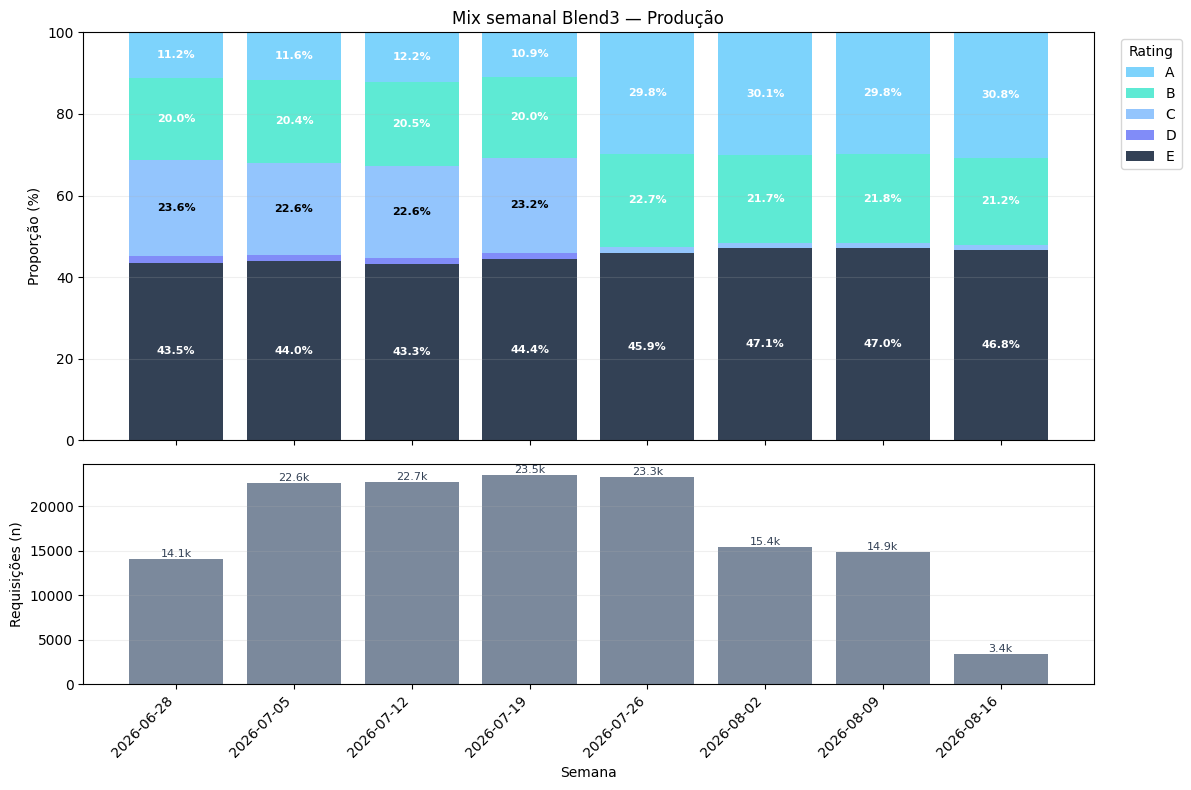

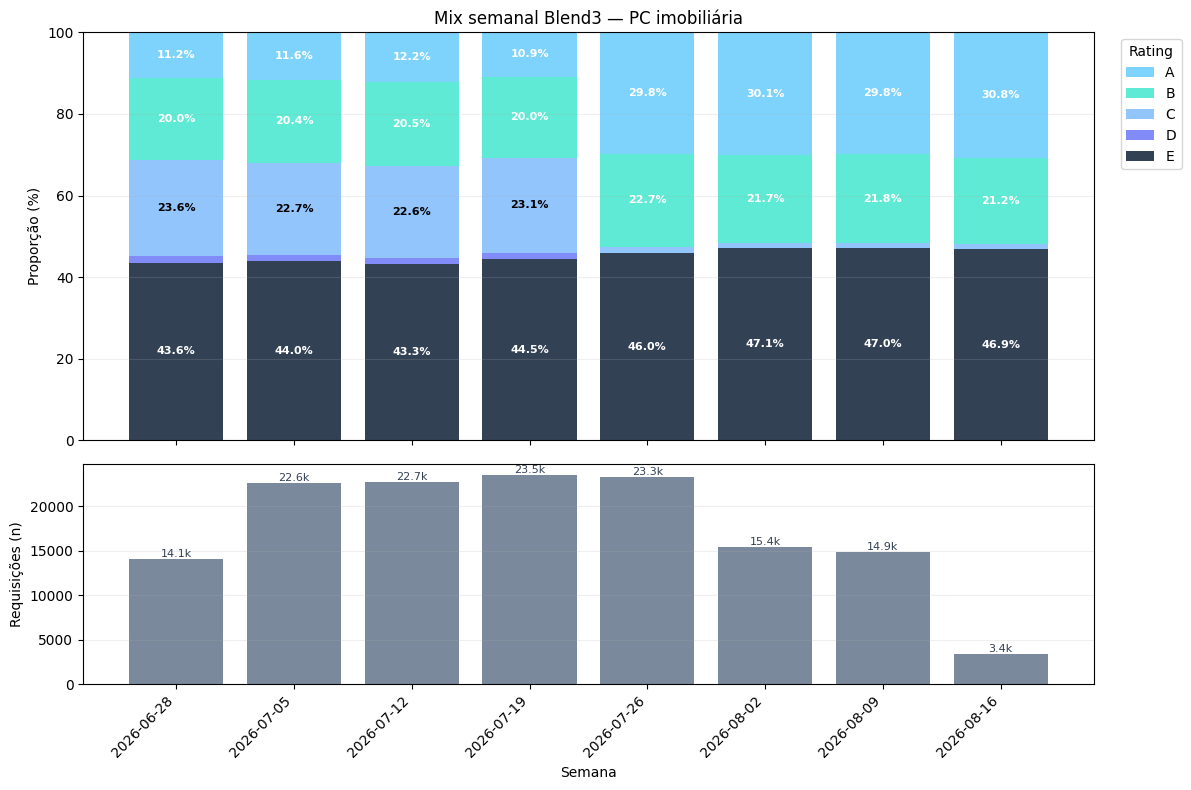

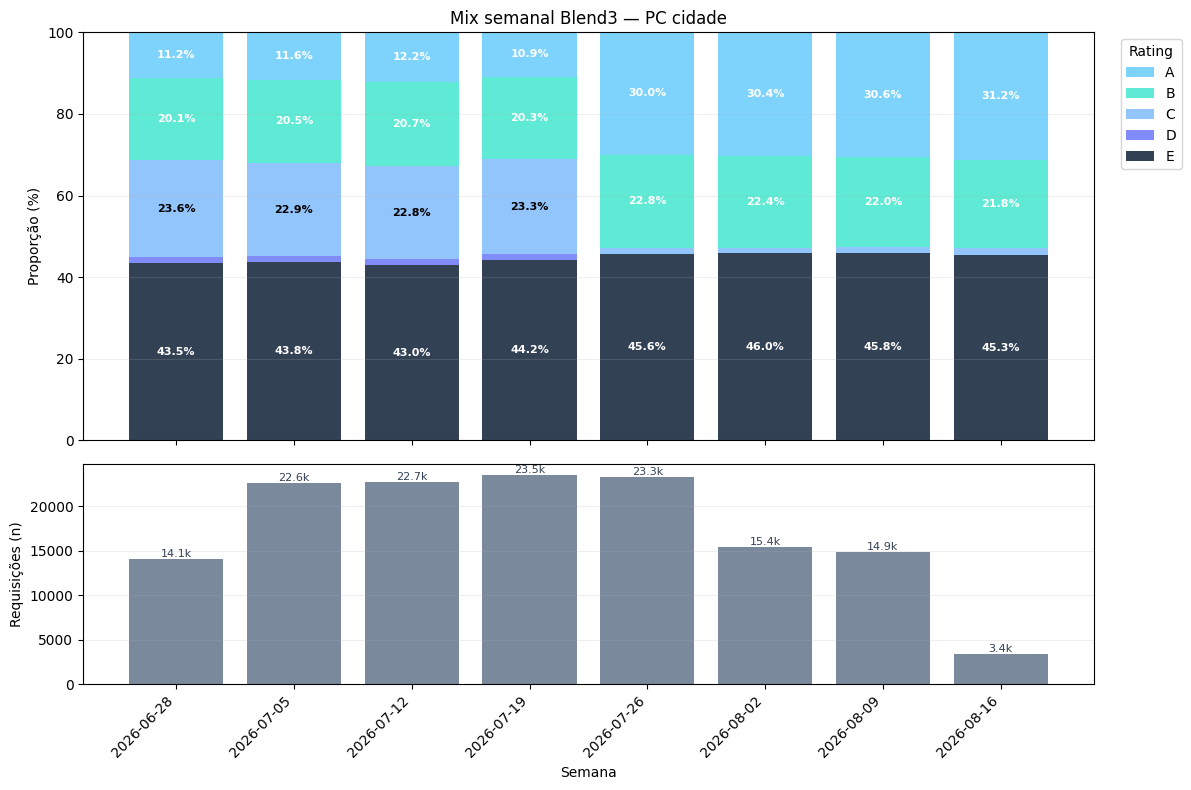

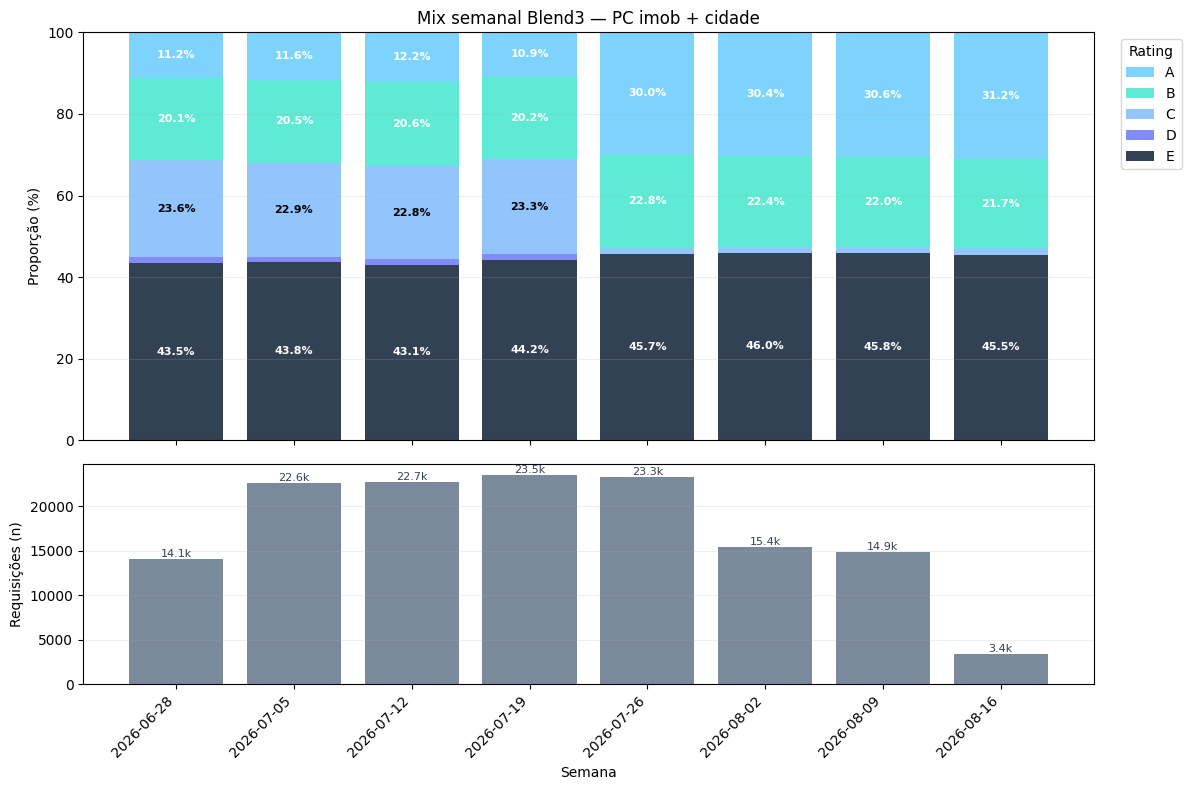

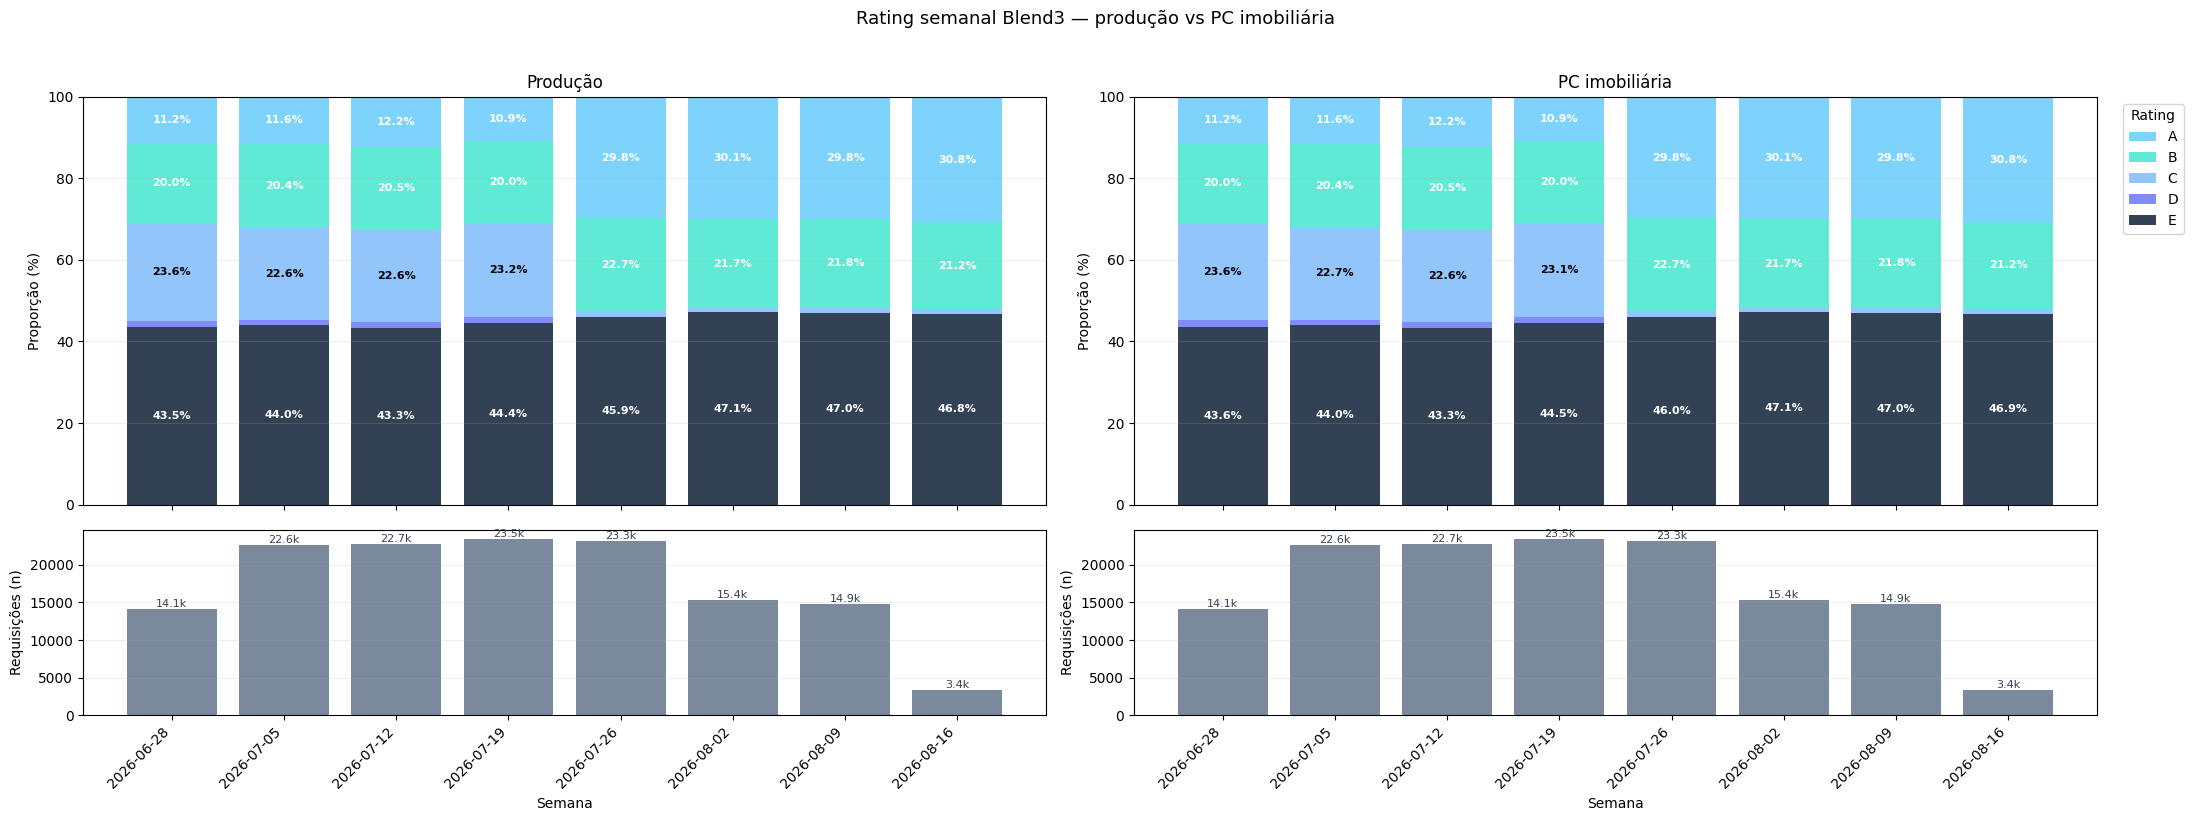

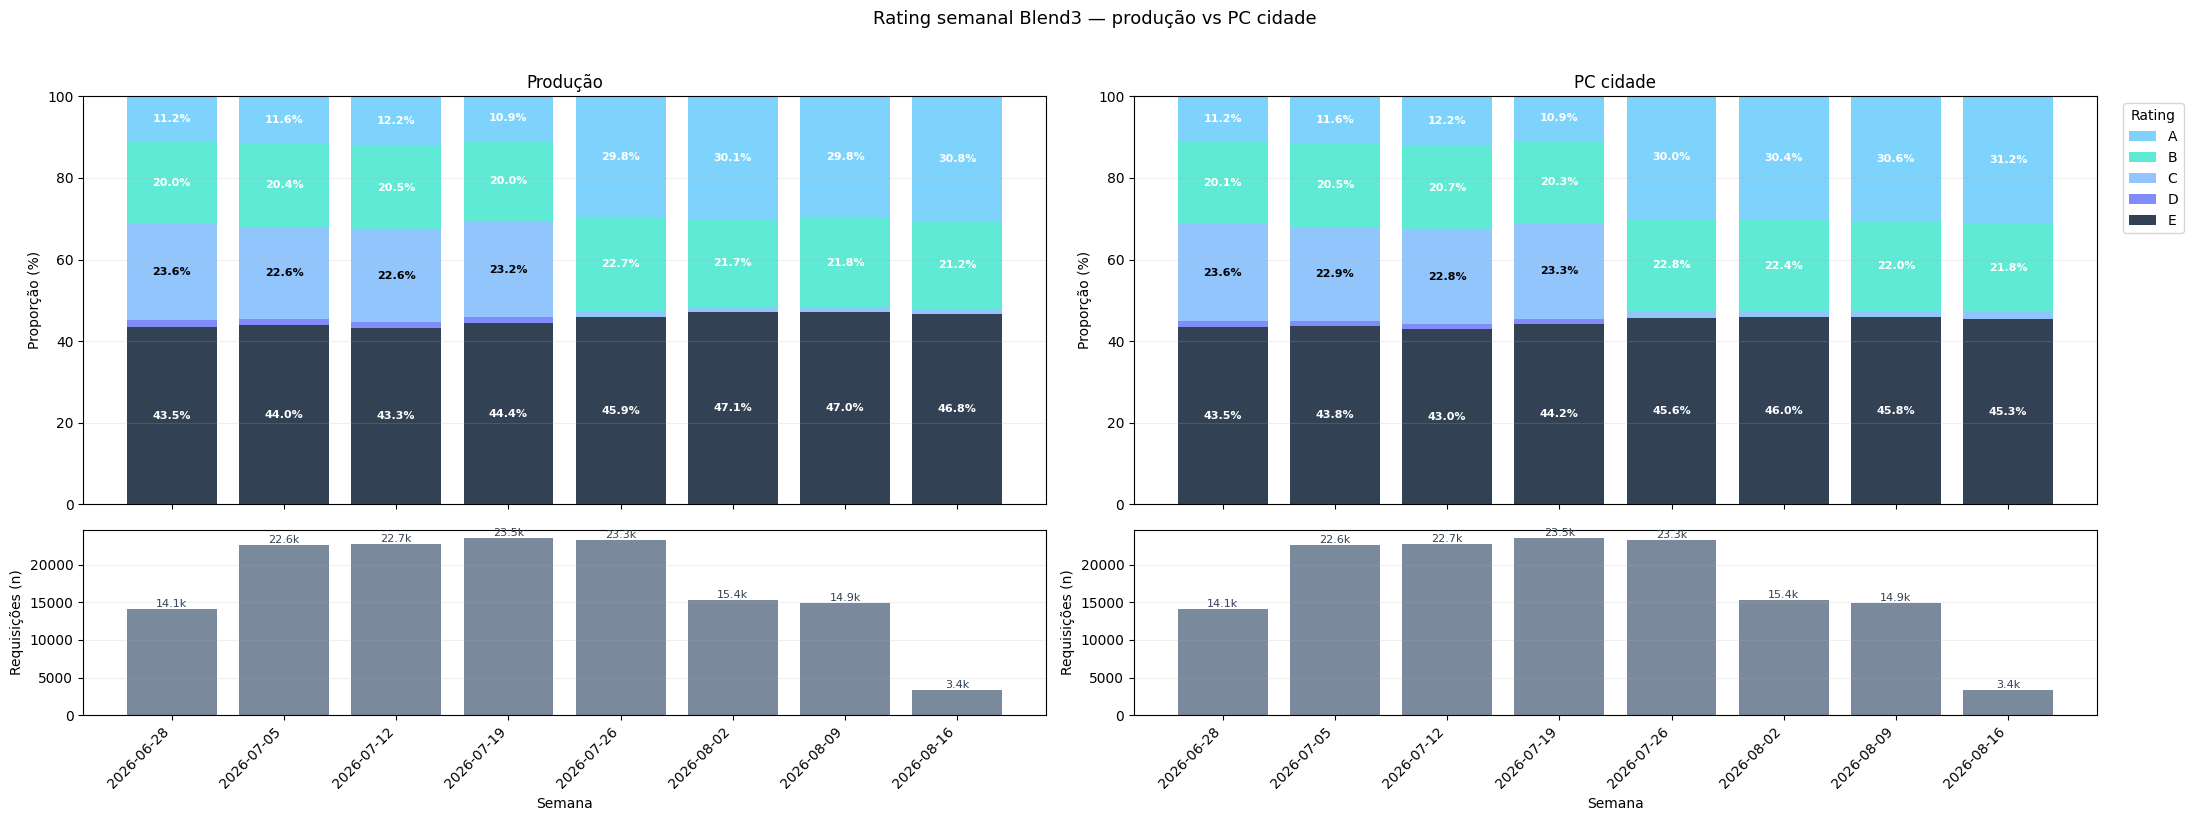

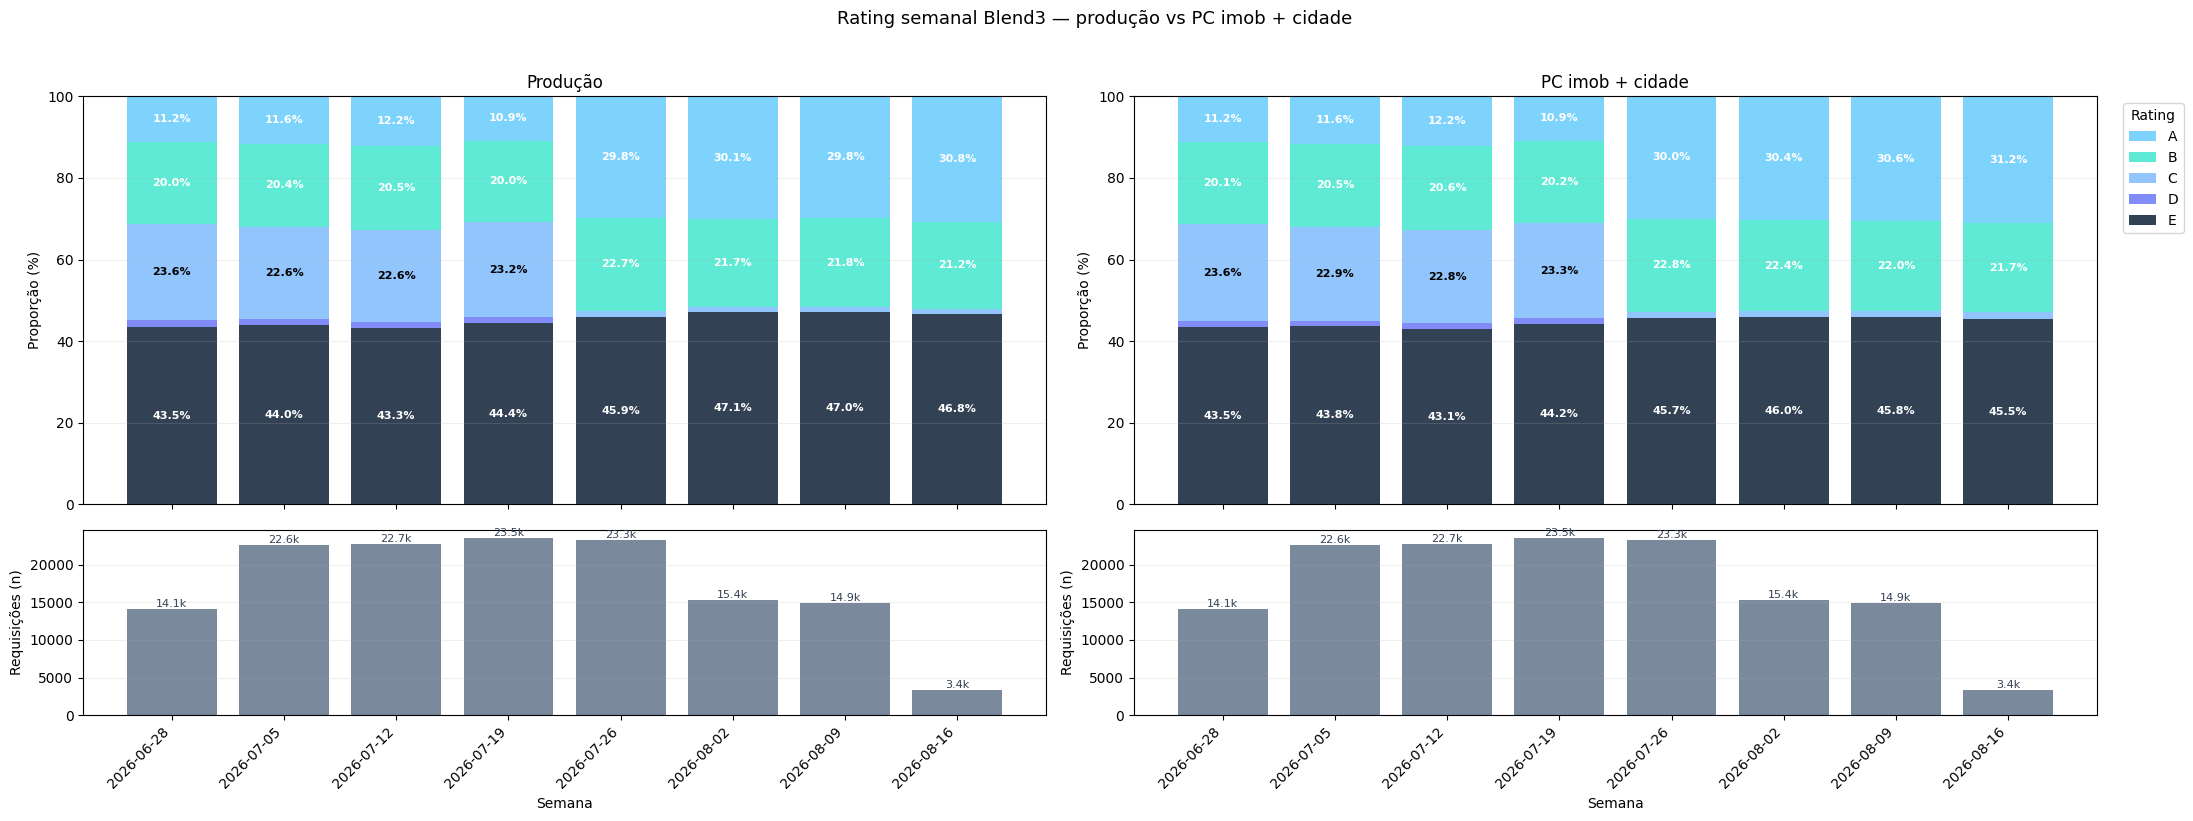

In [184]:
for scen, label in [
    ("prod", "Produção"),
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_weekly_mix(
        df_blend3_cmp,
        category_col=f"rating_manual_blend3_{scen}",
        title=f"Mix semanal Blend3 — {label}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=3.0,
    )

for scen, label in [
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_weekly_rating_comparison(
        df_blend3_cmp,
        title=f"Rating semanal Blend3 — produção vs {label}",
        production_rating_col="rating_manual_blend3_prod",
        simulated_rating_col=f"rating_manual_blend3_{scen}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
        production_title="Produção",
        simulated_title=label,
    )


### Blend3 — matriz de migração

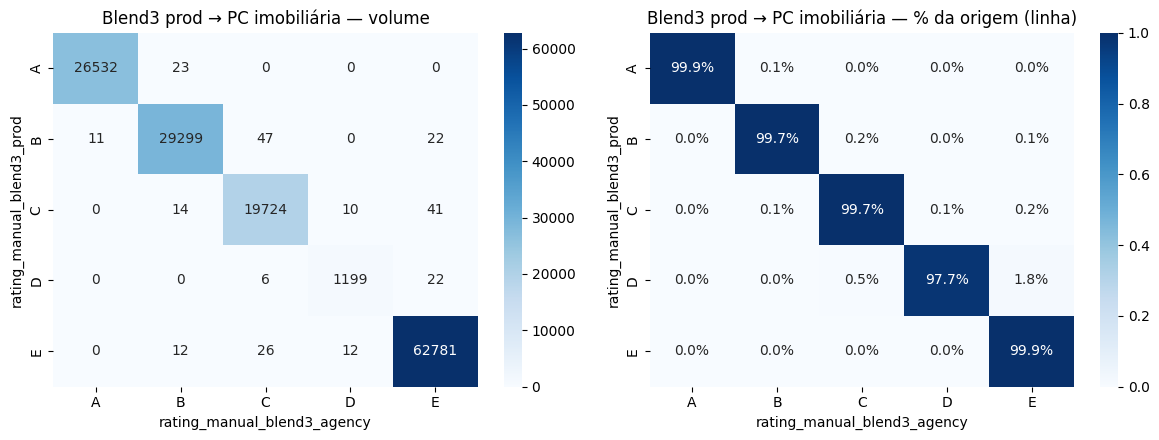

Blend3 prod → PC imobiliária: n=139,781 | permanência=99.8%


rating_manual_blend3_agency,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,26532,23,0,0,0,26555
B,11,29299,47,0,22,29379
C,0,14,19724,10,41,19789
D,0,0,6,1199,22,1227
E,0,12,26,12,62781,62831


rating_manual_blend3_agency,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,0.999,0.001,0.000,0.000,0.000,1.0
B,0.000,0.997,0.002,0.000,0.001,1.0
C,0.000,0.001,0.997,0.001,0.002,1.0
D,0.000,0.000,0.005,0.977,0.018,1.0
E,0.000,0.000,0.000,0.000,0.999,1.0


ValueError: Length of ascending (3) != length of by (2)

In [185]:
from importlib import reload
import funcoes_monitoramento as _fm_mon
reload(_fm_mon)
from funcoes_monitoramento import build_rating_mismatch_table, build_rating_match_summary

for scen, label in [
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_rating_migration(
        df_blend3_cmp,
        "rating_manual_blend3_prod",
        f"rating_manual_blend3_{scen}",
        f"Blend3 prod → {label}",
    )


### Blend4 — mix semanal (domingo a sábado)

In [ ]:
for scen, label in [
    ("prod", "Produção"),
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_weekly_mix(
        df_blend4_cmp,
        category_col=f"rating_manual_blend4_{scen}",
        title=f"Mix semanal Blend4 — {label}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        legend_title="Rating",
        min_label_pct=3.0,
    )

for scen, label in [
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_weekly_rating_comparison(
        df_blend4_cmp,
        title=f"Rating semanal Blend4 — produção vs {label}",
        production_rating_col="rating_manual_blend4_prod",
        simulated_rating_col=f"rating_manual_blend4_{scen}",
        category_order=RATING_ORDER,
        color_map=RATING_COLOR_MAP,
        text_color_map=RATING_TEXT_COLOR_MAP,
        reverse_stack=True,
        min_label_pct=3.0,
        production_title="Produção",
        simulated_title=label,
    )


### Blend4 — matriz de migração

In [ ]:
from importlib import reload
import funcoes_monitoramento as _fm_mon
reload(_fm_mon)
from funcoes_monitoramento import build_rating_mismatch_table, build_rating_match_summary

for scen, label in [
    ("agency", "PC imobiliária"),
    ("city", "PC cidade"),
    ("ambos", "PC imob + cidade"),
]:
    plot_rating_migration(
        df_blend4_cmp,
        "rating_manual_blend4_prod",
        f"rating_manual_blend4_{scen}",
        f"Blend4 prod → {label}",
    )


n contratos no join: 141424


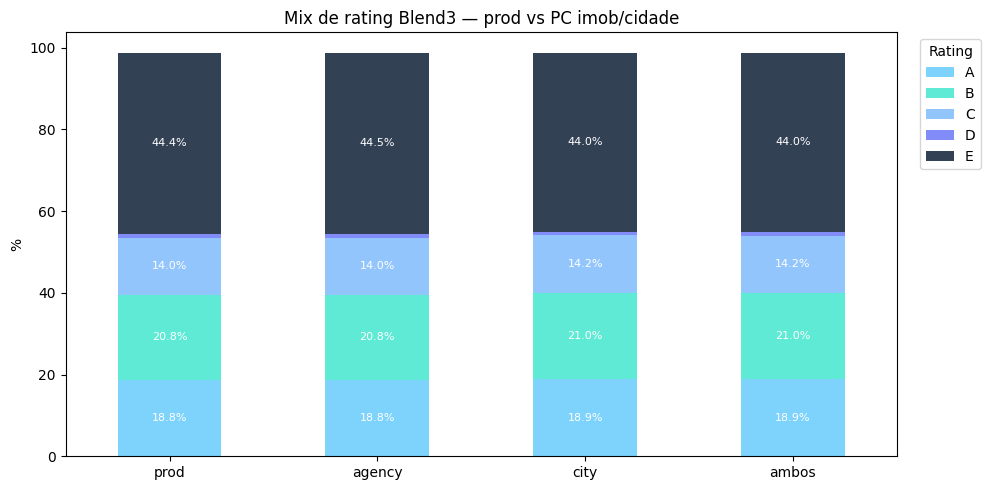

,prod,agency,city,ambos
A,18.8,18.8,18.9,18.9
B,20.8,20.8,21.0,21.0
C,14.0,14.0,14.2,14.2
D,0.9,0.9,0.8,0.8
E,44.4,44.5,44.0,44.0
NA,1.2,1.2,1.2,1.2


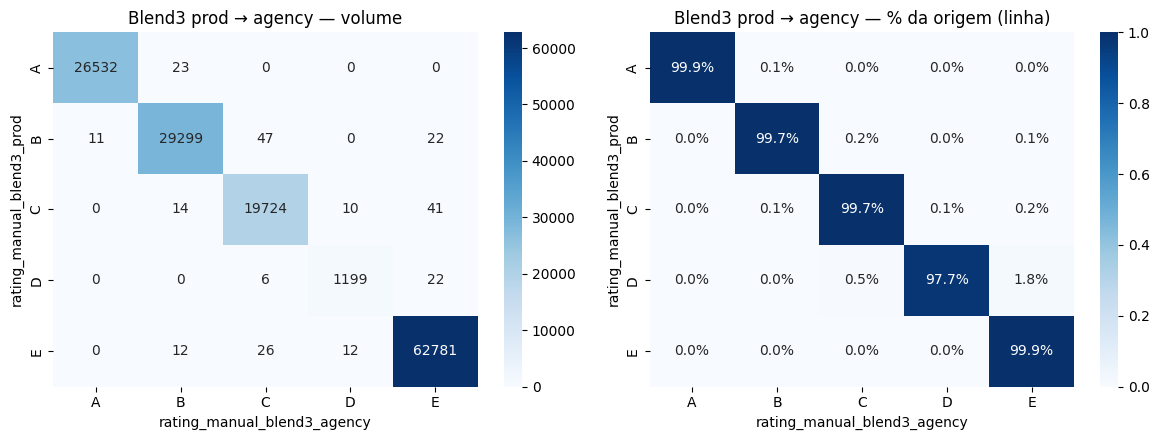

Blend3 prod → agency: n=139,781 | permanência=99.8%


rating_manual_blend3_agency,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,26532,23,0,0,0,26555
B,11,29299,47,0,22,29379
C,0,14,19724,10,41,19789
D,0,0,6,1199,22,1227
E,0,12,26,12,62781,62831


rating_manual_blend3_agency,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,0.999,0.001,0.000,0.000,0.000,1.0
B,0.000,0.997,0.002,0.000,0.001,1.0
C,0.000,0.001,0.997,0.001,0.002,1.0
D,0.000,0.000,0.005,0.977,0.018,1.0
E,0.000,0.000,0.000,0.000,0.999,1.0


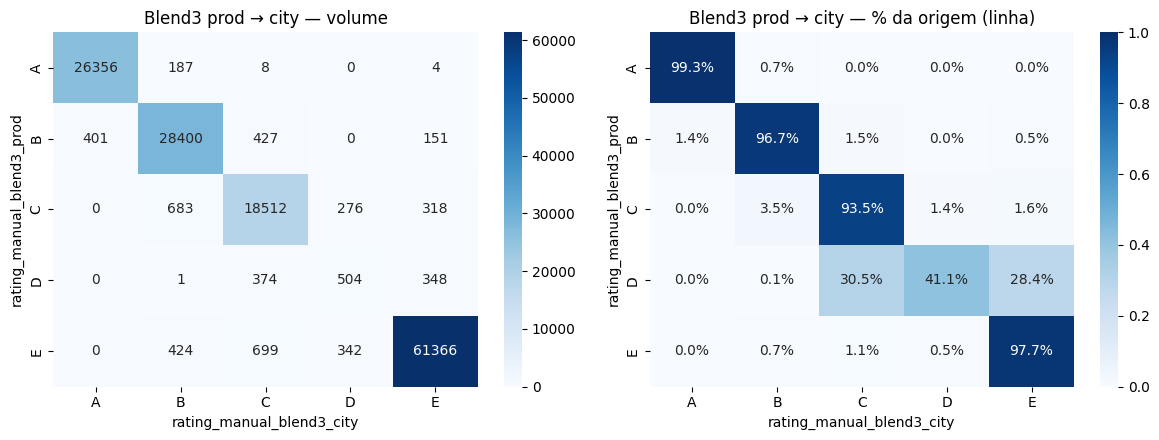

Blend3 prod → city: n=139,781 | permanência=96.7%


rating_manual_blend3_city,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,26356,187,8,0,4,26555
B,401,28400,427,0,151,29379
C,0,683,18512,276,318,19789
D,0,1,374,504,348,1227
E,0,424,699,342,61366,62831


rating_manual_blend3_city,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,0.993,0.007,0.000,0.000,0.000,1.0
B,0.014,0.967,0.015,0.000,0.005,1.0
C,0.000,0.035,0.935,0.014,0.016,1.0
D,0.000,0.001,0.305,0.411,0.284,1.0
E,0.000,0.007,0.011,0.005,0.977,1.0


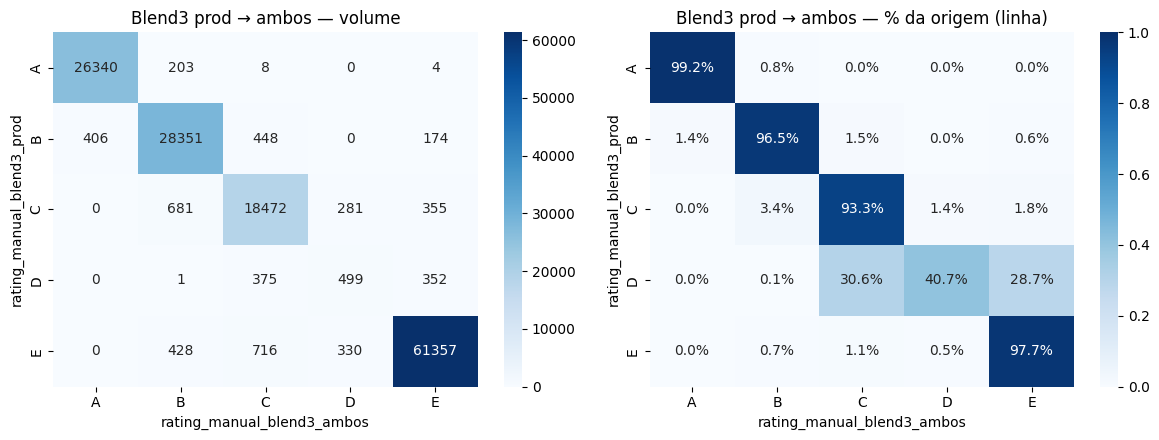

Blend3 prod → ambos: n=139,781 | permanência=96.6%


rating_manual_blend3_ambos,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,26340,203,8,0,4,26555
B,406,28351,448,0,174,29379
C,0,681,18472,281,355,19789
D,0,1,375,499,352,1227
E,0,428,716,330,61357,62831


rating_manual_blend3_ambos,A,B,C,D,E,total
rating_manual_blend3_prod,,,,,,
A,0.992,0.008,0.000,0.000,0.000,1.0
B,0.014,0.965,0.015,0.000,0.006,1.0
C,0.000,0.034,0.933,0.014,0.018,1.0
D,0.000,0.001,0.306,0.407,0.287,1.0
E,0.000,0.007,0.011,0.005,0.977,1.0


In [ ]:
# Weekly mix and migration live in the cells above (Join cenários PC + mix semanal + migração).

n contratos no join: 50439


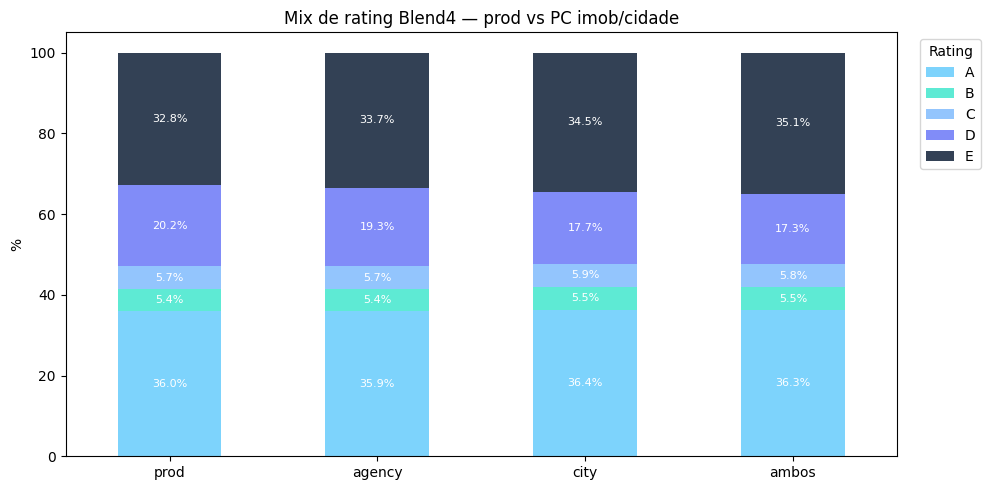

,prod,agency,city,ambos
A,36.0,35.9,36.4,36.3
B,5.4,5.4,5.5,5.5
C,5.7,5.7,5.9,5.8
D,20.2,19.3,17.7,17.3
E,32.8,33.7,34.5,35.1
NA,0.0,0.0,0.0,0.0


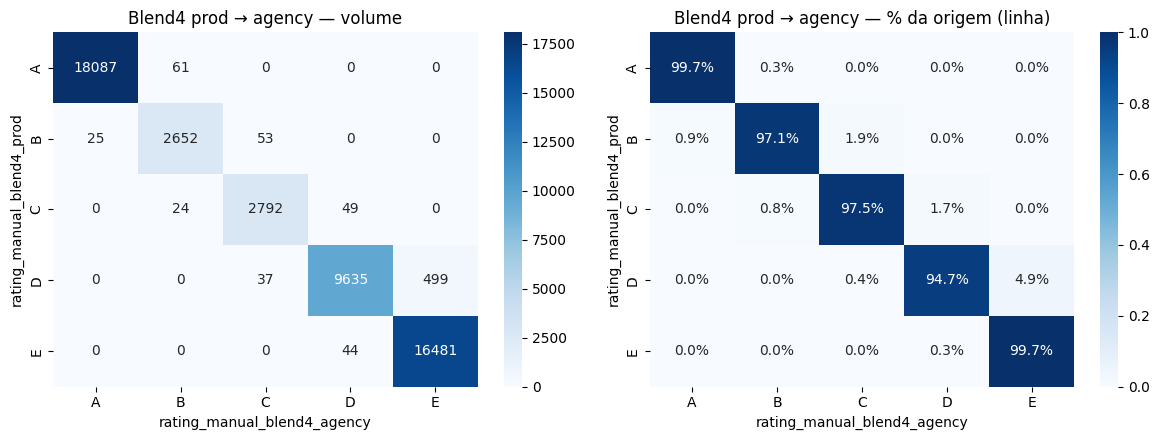

Blend4 prod → agency: n=50,439 | permanência=98.4%


rating_manual_blend4_agency,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,18087,61,0,0,0,18148
B,25,2652,53,0,0,2730
C,0,24,2792,49,0,2865
D,0,0,37,9635,499,10171
E,0,0,0,44,16481,16525


rating_manual_blend4_agency,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,0.997,0.003,0.000,0.000,0.000,1.0
B,0.009,0.971,0.019,0.000,0.000,1.0
C,0.000,0.008,0.975,0.017,0.000,1.0
D,0.000,0.000,0.004,0.947,0.049,1.0
E,0.000,0.000,0.000,0.003,0.997,1.0


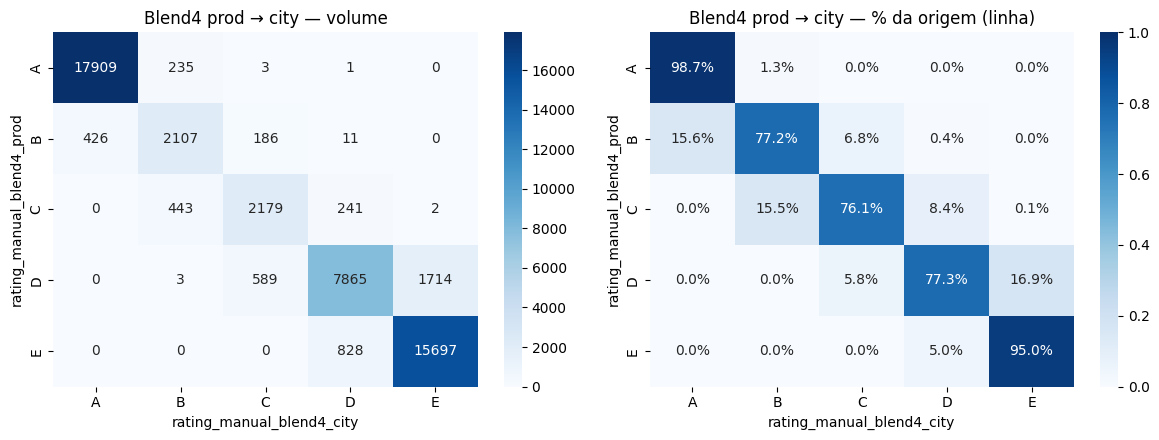

Blend4 prod → city: n=50,439 | permanência=90.7%


rating_manual_blend4_city,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,17909,235,3,1,0,18148
B,426,2107,186,11,0,2730
C,0,443,2179,241,2,2865
D,0,3,589,7865,1714,10171
E,0,0,0,828,15697,16525


rating_manual_blend4_city,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,0.987,0.013,0.000,0.000,0.000,1.0
B,0.156,0.772,0.068,0.004,0.000,1.0
C,0.000,0.155,0.761,0.084,0.001,1.0
D,0.000,0.000,0.058,0.773,0.169,1.0
E,0.000,0.000,0.000,0.050,0.950,1.0


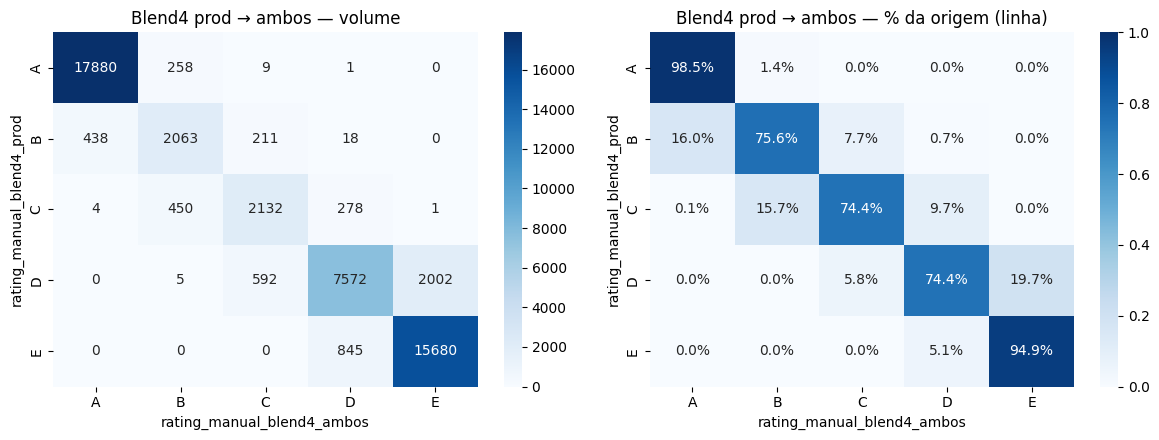

Blend4 prod → ambos: n=50,439 | permanência=89.9%


rating_manual_blend4_ambos,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,17880,258,9,1,0,18148
B,438,2063,211,18,0,2730
C,4,450,2132,278,1,2865
D,0,5,592,7572,2002,10171
E,0,0,0,845,15680,16525


rating_manual_blend4_ambos,A,B,C,D,E,total
rating_manual_blend4_prod,,,,,,
A,0.985,0.014,0.000,0.000,0.000,1.0
B,0.160,0.756,0.077,0.007,0.000,1.0
C,0.001,0.157,0.744,0.097,0.000,1.0
D,0.000,0.000,0.058,0.744,0.197,1.0
E,0.000,0.000,0.000,0.051,0.949,1.0


In [ ]:
# Blend4 weekly mix and migration are in the cells above.